In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
import os
import re 
from Functions.functions  import calculate_IAF, remove_subjects_by_criteria, print_subjects_remaining, append_or_merge_to_existing_sheet, IAF2columns, report_IAF_by_sensor
from Functions.graphs_functions import plot_component_grid_by_group
from Functions.aproach import process_iaf_fooof_rois

d:\flujo_portables\env_recombat\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load psd Multicenter

In [2]:
path_common = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\features_alternative_pipeline"
psd_Dortmund = pd.read_feather(rf"{path_common}\psd\psd_Dortmund_EyesClosed_scorEpochs_zscore_long.feather")
psd_AR = pd.read_feather(rf"{path_common}\psd\psd_Argentina_rs_scorEpochs_zscore_long.feather")
psd_CL = pd.read_feather(rf"{path_common}\psd\psd_Chile_rs_scorEpochs_zscore_long.feather")
psd_cuba = pd.read_feather(rf"{path_common}\psd\psd_Cuba_CE_scorEpochs_zscore_long.feather")
psd_Med_ld = pd.read_feather(rf"{path_common}\psd\psd_Medellin_ld_CE_scorEpochs_zscore_long.feather")
psd_Med_hd = pd.read_feather(rf"{path_common}\psd\psd_Medellin_hd_CE_scorEpochs_zscore_long.feather")
psd_CAUEEG = pd.read_feather(rf"{path_common}\psd\psd_CAUEEG_rs_scorEpochs_zscore_long.feather")
psd_SRM = pd.read_feather(rf"{path_common}\psd\psd_Oslo_resteyesc_scorEpochs_zscore_long.feather")
psd_poland = pd.read_feather(rf"{path_common}\psd\psd_Poland_rest_scorEpochs_zscore_long.feather")
psd_greece = pd.read_feather(rf"{path_common}\psd\psd_GREECE_eyesclosed_scorEpochs_zscore_long.feather")
psd_Madrid = pd.read_feather(rf"{path_common}\psd\psd_Madrid_rest_scorEpochs_zscore_long.feather")
psd_CAUEEG['Sensors'] = psd_CAUEEG['Sensors'].replace({'T5': 'P7', 'T6': 'P8'})
psd_CAUEEG.replace({'SITE':{'CAUEEG': 'Seoul'}},inplace=True)
psd_CAUEEG.dropna(subset=['group'], inplace=True)
psd_greece['Sensors'] = psd_greece['Sensors'].replace({'T5': 'P7', 'T6': 'P8'})
psd_greece.replace({'SITE':{'GREECE': 'Greece'}},inplace=True)
psd_Med_ld.replace({'group': {'CTR': 'HC', 'GU': 'HC', 'DCL': 'MCI', 'GG':'ACr'}},inplace=True)
psd_Med_hd.replace({'group': {'CTR': 'HC', 'G2': 'HC', 'DCL': 'MCI','G1':'ACr'}},inplace=True)

## Step 1: Filter criterials QA

In [3]:
QA_Dortmund = pd.read_excel(rf"{path_common}\QA\QC_Dortmund.xlsx")
QA_AR = pd.read_excel(rf"{path_common}\QA\QC_Argentina.xlsx")
QA_CL = pd.read_excel(rf"{path_common}\QA\QC_Chile.xlsx")
QA_cuba = pd.read_excel(rf"{path_common}\QA\QC_Cuba.xlsx")
QA_Med_ld = pd.read_excel(rf"{path_common}\QA\QC_Medellin_ld.xlsx")
QA_Med_hd = pd.read_excel(rf"{path_common}\QA\QC_Medellin_hd.xlsx")
QA_CAUEEG = pd.read_excel(rf"{path_common}\QA\QC_CAUEEG.xlsx")
QA_SRM = pd.read_excel(rf"{path_common}\QA\QC_Oslo.xlsx")
QA_poland = pd.read_excel(rf"{path_common}\QA\QC_Poland.xlsx")
QA_greece = pd.read_excel(rf"{path_common}\QA\QC_GREECE.xlsx")
QA_Madrid = pd.read_excel(rf"{path_common}\QA\QC_Madrid.xlsx") # Falta sacarlo

In [4]:
subj_drop_Dortmund = QA_Dortmund[QA_Dortmund['len_epochs'] < 24]['subject']
subj_drop_AR = QA_AR[QA_AR['len_epochs'] < 24]['subject']
subj_drop_CL = QA_CL[QA_CL['len_epochs'] < 24]['subject']
subj_drop_cuba = QA_cuba[QA_cuba['len_epochs'] < 24]['subject']
subj_drop_Med_ld = QA_Med_ld[QA_Med_ld['len_epochs'] < 24]['subject']
subj_drop_Med_hd = QA_Med_hd[QA_Med_hd['len_epochs'] < 24]['subject']
subj_drop_CAUEEG = QA_CAUEEG[QA_CAUEEG['len_epochs'] < 24]['subject']
subj_drop_SRM = QA_SRM[QA_SRM['len_epochs'] < 24]['subject']
subj_drop_poland = QA_poland[QA_poland['len_epochs'] < 24]['subject']
subj_drop_greece = QA_greece[QA_greece['len_epochs'] < 24]['subject']
subj_drop_Madrid = QA_Madrid[QA_Madrid['len_epochs'] < 24]['subject']

In [5]:
print("subject deleted Dortmund: ", len(subj_drop_Dortmund))
print("subject deleted AR: ", len(subj_drop_AR))
print("subject deleted CL: ", len(subj_drop_CL))
print("subject deleted cuba: ", len(subj_drop_cuba))
print("subject deleted Med_ld: ", len(subj_drop_Med_ld))
print("subject deleted Med_hd: ", len(subj_drop_Med_hd))
print("subject deleted CAUEEG: ", len(subj_drop_CAUEEG))
print("subject deleted SRM: ", len(subj_drop_SRM))
print("subject deleted poland: ", len(subj_drop_poland))
print("subject deleted greece: ", len(subj_drop_greece))
print('subject deleted Madrid: ', len(subj_drop_Madrid))

subject deleted Dortmund:  1
subject deleted AR:  0
subject deleted CL:  0
subject deleted cuba:  0
subject deleted Med_ld:  0
subject deleted Med_hd:  0
subject deleted CAUEEG:  36
subject deleted SRM:  0
subject deleted poland:  0
subject deleted greece:  0
subject deleted Madrid:  0


In [6]:
# Filtrar el DataFrame eliminando esos sujetos
psd_Dortmund = psd_Dortmund[~psd_Dortmund['subject'].isin(subj_drop_Dortmund)]
psd_CAUEEG = psd_CAUEEG[~psd_CAUEEG['subject'].isin(subj_drop_CAUEEG)]

## Calculate IAF

In [7]:
canonical_bands={'delta':(1.5,6),
        'theta':(6,8.5),
        'alpha1':(8.5,10.5),
        'alpha2':(10.5,12.5),
        'beta1':(12.5,18.5),
        'beta2':(18.5,21),
        'beta3':(21,30),
        'gamma':(30,40)
}

In [8]:
path_psd= rf'{path_common}\AIF_Babiloni'
plot = False
data_IAF_AR = calculate_IAF(psd_AR,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_CL = calculate_IAF(psd_CL,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_Med_ld = calculate_IAF(psd_Med_ld,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_Med_hd = calculate_IAF(psd_Med_hd,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_cuba = calculate_IAF(psd_cuba,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_Dortmund = calculate_IAF(psd_Dortmund,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_CAUEEG = calculate_IAF(psd_CAUEEG,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_SRM = calculate_IAF(psd_SRM,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_poland = calculate_IAF(psd_poland,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_greece = calculate_IAF(psd_greece,plot= plot, path=path_psd, canonic_bands= canonical_bands)
data_IAF_Madrid = calculate_IAF(psd_Madrid,plot= plot, path=path_psd, canonic_bands= canonical_bands)

beta (10.59375, 30)
beta (10.59375, 30)
beta (10.7890625, 30)
beta (10.7890625, 30)
beta (10.59375, 30)
beta (10.7890625, 30)
beta (10.59375, 30)
beta (10.3984375, 30)
beta (12.7421875, 30)
beta (13.1328125, 30)
beta (12.7421875, 30)
beta (15.28125, 30)
beta (13.1328125, 30)
beta (12.7421875, 30)
beta (13.1328125, 30)
beta (12.7421875, 30)
beta (10.984375, 30)
beta (10.984375, 30)
beta (10.7890625, 30)
beta (10.984375, 30)
beta (10.984375, 30)


beta (11.5703125, 30)
beta (11.375, 30)
beta (10.984375, 30)
beta (11.5703125, 30)
beta (11.5703125, 30)
beta (10.3984375, 30)
beta (11.765625, 30)
beta (10.3984375, 30)
beta (10.7890625, 30)
beta (10.3984375, 30)
beta (10.3984375, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (11.375, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (10.984375, 30)
beta (10.984375, 30)
beta (12.9375, 30)
beta (12.9375, 30)
beta (13.1328125, 30)
beta (15.8671875, 30)
beta (12.9375, 30)
beta (12.7421875, 30)
beta (12.9375, 30)
beta (12.9375, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (11.375, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (10.984375, 30)
beta (10.984375, 30)
beta (10.984375, 30)
beta (11.5703125, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (11.1796875, 30)
beta (10.7890625, 30)
beta (12.9375, 30)
beta (12.9375, 30)
beta (13.328125, 30)
beta (12.9375, 30)
beta (12.9

In [9]:
Sites = {
    "Argentina": data_IAF_AR,
    "Chile": data_IAF_CL,
    "Cuba": data_IAF_cuba,
    "Medellin_ld": data_IAF_Med_ld,
    "Medellin_hd": data_IAF_Med_hd,
    "Dortmund": data_IAF_Dortmund,
    "Seoul": data_IAF_CAUEEG,
    "Oslo": data_IAF_SRM,
    "Poland": data_IAF_poland,
    "Greece": data_IAF_greece,
    "Madrid": data_IAF_Madrid
}

path_report = rf'{path_common}\AIF_Babiloni\report_IAF_by_sensor.xlsx'
report_IAF_by_sensor(Sites, path_report)
# Listas para almacenar los informes de cada tipo
general_reports = []
controls_reports = []
patients_reports = []

# Definir los grupos de interés
controls_groups = ['HC']
patients_groups = ['MCI']

# Iterar por cada base de datos
for name, data in Sites.items():
    # Aplicar la eliminación a los diferentes conjuntos de datos después de calcular el IAF
    channels = data['Sensors'].unique()
    df = remove_subjects_by_criteria(data, channels)
    Sites[name] = df
    
    # Informe General
    remaining_by_channel = df.groupby('Sensors')['subject'].nunique()
    total_remaining = df['subject'].nunique()
    general_report = pd.DataFrame({
        'remaining_subject': [total_remaining] * len(channels),
    })
    general_report["SITE"] = name
    general_report["Sensor"] = list(channels)
    general_reports.append(general_report)  # Agregar a la lista
    
    # Informe de Controles
    controls_data = df[df['group'].isin(controls_groups) & df['Sensors'].isin(list(channels))]
    remaining_hc_by_channel = controls_data.groupby('Sensors')['subject'].nunique()
    controls_report = pd.DataFrame({
        'remaining_subject': remaining_hc_by_channel
    })
    controls_report["SITE"] = name
    controls_report["Sensor"] = list(channels)
    controls_reports.append(controls_report)  # Agregar a la lista
    
    # Informe de Sujetos Enfermos
    patients_data = df[df['group'].isin(patients_groups) & df['Sensors'].isin(list(channels))]
    remaining_mci_by_channel = patients_data.groupby('Sensors')['subject'].nunique()
    patients_report = pd.DataFrame({
        'remaining_subject': remaining_mci_by_channel
    })
    patients_report["SITE"] = name
    patients_report["Sensor"] = list(channels)
    patients_reports.append(patients_report)  # Agregar a la lista

# Concatenar los informes de todas las bases de datos
general_reports_combined = pd.concat(general_reports, ignore_index=True)
controls_reports_combined = pd.concat(controls_reports, ignore_index=True)
patients_reports_combined = pd.concat(patients_reports, ignore_index=True)


¡Informe generado con éxito!


Filtrar los df para que elimine los sujetos que tienen un TF por debajo de 3 y que además los que el TF sea mayor a IAFp

filtrar a los canales de interés ( P7, P8, O1 y O2)

Se elimina si el sujeto en un solo canal no cumple con los criterios

In [10]:
append_or_merge_to_existing_sheet(path_report, general_reports_combined, "General_report", merge_on=["SITE", "Sensor"])
append_or_merge_to_existing_sheet(path_report, controls_reports_combined, "Controls_report", merge_on=["SITE", "Sensor"])
append_or_merge_to_existing_sheet(path_report, patients_reports_combined, "MCI_report", merge_on=["SITE", "Sensor"])


In [11]:
filters_IAFs_database = pd.concat(Sites.values(), ignore_index=True)
filters_IAFs_database = filters_IAFs_database[filters_IAFs_database['Sensors'].isin(['FP1','FP2','C3','C4','P7', 'P8', 'O1', 'O2'])].reset_index(drop=True)
hc_data = filters_IAFs_database[filters_IAFs_database['group'].isin(['HC'])]
mci_data  = filters_IAFs_database[filters_IAFs_database['group'].isin(['MCI'])]


In [12]:
# Selecciona solo columnas numéricas
numeric_df = filters_IAFs_database.select_dtypes(include=[np.number])

# Cuenta ceros por columna
zero_counts = (numeric_df == 0).sum()

# Muestra columnas con al menos un cero
columns_with_zeros = zero_counts[zero_counts > 0]
print(columns_with_zeros)


Series([], dtype: int64)


In [13]:
# Ver en qué filas la potencia absoluta de BGF1 o BGF2 es exactamente cero
mask_bgf_zero = (filters_IAFs_database['pw_ab_BGF1'] == 0) | (filters_IAFs_database['pw_ab_BGF2'] == 0)

# Mostrar las filas problemáticas con las columnas relevantes
cols = ['subject', 'Sensors', 'SITE', 'TF', 'IAFp', 'BGF1_Band', 'BGF2_Band', 'pw_ab_BGF1', 'pw_ab_BGF2']
print(filters_IAFs_database.loc[mask_bgf_zero, cols])


Empty DataFrame
Columns: [subject, Sensors, SITE, TF, IAFp, BGF1_Band, BGF2_Band, pw_ab_BGF1, pw_ab_BGF2]
Index: []


In [14]:
# Detectar bandas de ancho cero (inicio == fin) en BGF1 y BGF2
mask_bgf1_zero_width = filters_IAFs_database['BGF1_Band'].apply(lambda x: isinstance(x, tuple) and x[0] == x[1])
mask_bgf2_zero_width = filters_IAFs_database['BGF2_Band'].apply(lambda x: isinstance(x, tuple) and x[0] == x[1])

# Mostrar los casos con problema en BGF1
print("Casos con ancho cero en BGF1:")
print(filters_IAFs_database[mask_bgf1_zero_width][['SITE', 'BGF1_Band']])

# Mostrar los casos con problema en BGF2
print("\nCasos con ancho cero en BGF2:")
print(filters_IAFs_database[mask_bgf2_zero_width][['SITE', 'BGF2_Band']])


Casos con ancho cero en BGF1:
Empty DataFrame
Columns: [SITE, BGF1_Band]
Index: []

Casos con ancho cero en BGF2:
Empty DataFrame
Columns: [SITE, BGF2_Band]
Index: []


In [15]:
# Seleccionar columnas numéricas (para evitar errores con columnas de tipo object)
numeric_cols = filters_IAFs_database.select_dtypes(include=[np.number]).columns

# Filtrar el DataFrame por esas columnas + SITE
df_numeric_with_site = filters_IAFs_database[numeric_cols.tolist() + ['SITE']]

# Crear una máscara booleana donde hay ceros
mask_zeros = df_numeric_with_site[numeric_cols] == 0

# Combinar con la columna SITE
df_zeros = df_numeric_with_site.loc[mask_zeros.any(axis=1), ['SITE'] + numeric_cols.tolist()]

# Mostrar dónde hay ceros (por SITE y canal)
for col in numeric_cols:
    subset = df_zeros[df_zeros[col] == 0]
    if not subset.empty:
        print(f"\nCanal: {col}")
        print(subset['SITE'].value_counts())


In [16]:
filters_IAFs_database[filters_IAFs_database['group'] == 'HC'].groupby('SITE')['Sensors'].describe()

,count,unique,top,freq
SITE,,,,
Argentina,144,8,FP1,18
Chile,104,8,FP1,13
Cuba,1816,8,FP1,227
Dortmund,2736,8,FP1,342
Greece,32,8,FP1,4
Madrid,152,8,FP1,19
Medellin_hd,464,8,FP1,58
Medellin_ld,456,8,FP1,57
Oslo,800,8,FP1,100


In [17]:
filters_IAFs_database[filters_IAFs_database['group'] == 'MCI'].groupby('SITE')['Sensors'].describe()

,count,unique,top,freq
SITE,,,,
Madrid,216,8,FP1,27
Medellin_hd,56,8,FP1,7
Medellin_ld,24,8,FP1,3
Seoul,2256,8,FP1,282


## Estimate FOOOFGroup

In [18]:
import numpy as np
import pandas as pd
from fooof import FOOOFGroup
from fooof.bands import Bands

# Simulación de datos (reemplaza con los datos reales)
freqs = np.array(filters_IAFs_database['freqs'].tolist())
psds = np.array(filters_IAFs_database['psd'].tolist())

# Definir bandas de interés
bands = Bands({'extalpha': [5, 14]})

# Inicializar el modelo FOOOFGroup
fg = FOOOFGroup(peak_width_limits=[1, 8], max_n_peaks=8, aperiodic_mode='fixed', verbose=False)
freq_range = [1, 40]

# Ajustar el modelo a todos los espectros
fg.fit(freqs[0], psds, freq_range)

# Extraer parámetros aperiódicos
exps_temp = fg.get_params('aperiodic_params', 'exponent')
offset_temp = fg.get_params('aperiodic_params', 'offset')

# Extraer bondad de ajuste
r2s = fg.get_params('r_squared')
errors = fg.get_params('error')

# Diccionario para almacenar CF por banda y otros valores
cf_by_band = {band: [] for band in bands.labels}
psd_oscilatorio = []
oscilatory = []
aperiodic = []
freqs_fooof = []

# Extraer picos y oscilaciones
for idx, result in enumerate(fg.get_results()):
    peaks = result.peak_params
    fm = fg.get_fooof(ind=idx, regenerate=True)
    aperiodic.append(fm._ap_fit)
    oscilatory.append(fm._peak_fit)

    freqs_fooof.append(fm.freqs)
    
    for band, (low, high) in zip(bands.labels, bands.definitions):
        band_peaks = [p[0] for p in peaks if low <= p[0] <= high]
        cf_by_band[band].append(band_peaks[0] if band_peaks else np.nan)

# Convertir a NumPy arrays
cf_by_band = {band: np.array(values) for band, values in cf_by_band.items()}
psd_oscilatorio = np.array(psd_oscilatorio)

# Agregar columnas al DataFrame

filters_IAFs_database['exponent'] = exps_temp
filters_IAFs_database['offset'] = offset_temp
filters_IAFs_database['r2'] = r2s
filters_IAFs_database['error'] = errors
filters_IAFs_database['oscilatory_psd'] = oscilatory
filters_IAFs_database['aperiodic_comp'] = aperiodic
filters_IAFs_database['freqs_fooof'] = freqs_fooof

# Agregar los CFs por banda
for band in bands.labels:
    filters_IAFs_database[f'CF_{band}'] = cf_by_band[band]

# Mostrar primeras filas del DataFrame actualizado
print(filters_IAFs_database.head())



C:\Users\Luisa\AppData\Local\Temp\ipykernel_19232\3056035221.py:3: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOFGroup


     subject Sensors group                                              freqs  \
0  sub-10002     FP1    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   
1  sub-10002     FP2    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   
2  sub-10002      C3    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   
3  sub-10002      C4    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   
4  sub-10002      O1    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   

                                                 psd       SITE  TF_original  \
0  [0.014498439335852986, 0.07293377413719658, 0....  Argentina     5.078125   
1  [0.005423741489834227, 0.014973713359726052, 0...  Argentina     4.296875   
2  [0.003624820127758638, 0.007121848295082885, 0...  Argentina     5.859375   
3  [0.0030235606847635616, 0.005070392560261014, ...  Argentina     5.273438   
4  [0.002907021014403464, 0.00871686823758495, 0....  Argentina     4.882812   

   TF_below_3  TF_corrected     

In [19]:
fg.print_results()

                                                                                                  
                                       FOOOF - GROUP RESULTS                                      
                                                                                                  
                           Number of power spectra in the Group: 14784                            
                                                                                                  
                        The model was run on the frequency range 1 - 40 Hz                        
                                 Frequency Resolution is 0.20 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                                                  
          

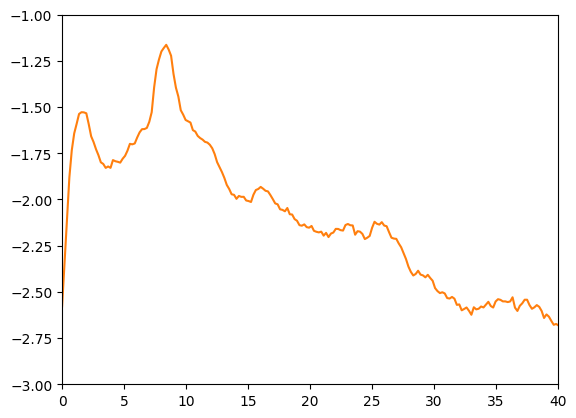

In [20]:
# Primer gráfico (sin escala logarítmica)
plt.plot(filters_IAFs_database.freqs_fooof[30], filters_IAFs_database.oscilatory_psd[30])

# Limitar el eje x de 0 a 40 Hz
plt.xlim(0, 40)

# Segundo gráfico (aplicando escala logarítmica base 10 solo a los valores del PSD)
plt.plot(filters_IAFs_database.freqs[30], np.log10(filters_IAFs_database.psd[30]))
plt.ylim(-3,-1)
# Mostrar los gráficos
plt.show()


                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                        The model was run on the frequency range 1 - 40 Hz                        
                                 Frequency Resolution is 0.20 Hz                                  
                                                                                                  
                            Aperiodic Parameters (offset, exponent):                              
                                         -1.3503, 0.7775                                          
                                                                                                  
                                       8 peaks were found:                                        
          

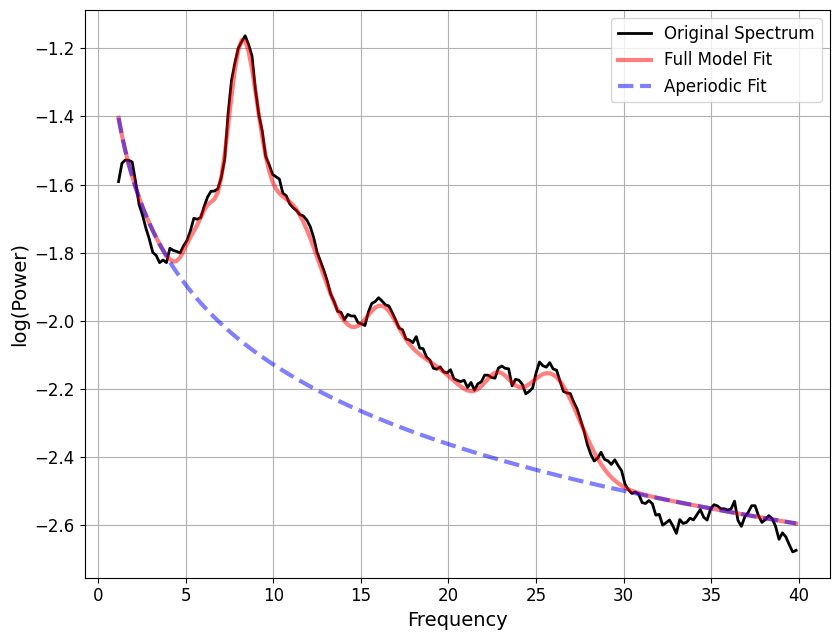

In [21]:
fm = fg.get_fooof(ind=30, regenerate=True)
# Print results and plot extracted model fit
fm.print_results()
fm.plot()

In [22]:
def band_pw(row, band_name):
    band_range = row[band_name]  
    
    if isinstance(band_range, tuple) and len(band_range) == 2:
        band_min, band_max = band_range
    else:
        return np.nan  # Si no es una tupla válida, devolver NaN
    
    freqs = np.array(row['freqs_fooof'])  # Frecuencias
    oscilatory_psd = np.array(10**row['oscilatory_psd']) # PSD oscilatoria
    
    mask = (freqs >= band_min) & (freqs <= band_max)
    return np.sum(oscilatory_psd[mask])  # Suma de la potencia en la banda

# Calcular las potencias absolutas
filters_IAFs_database['osc_pw_ab_delta'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'delta_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_theta'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'theta_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_BGF1'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'BGF1_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_BGF2'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'BGF2_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_BGF3'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'BGF3_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_beta'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'beta_Band'), axis=1)

filters_IAFs_database['osc_pw_ab_canonic_delta'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'delta_canonic_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_canonic_theta'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'theta_canonic_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_canonic_alpha1'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'alpha1_canonic_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_canonic_alpha2'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'alpha2_canonic_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_canonic_beta1'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'beta1_canonic_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_canonic_beta2'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'beta2_canonic_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_canonic_beta3'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'beta3_canonic_Band'), axis=1)
filters_IAFs_database['osc_pw_ab_canonic_gamma'] = filters_IAFs_database.apply(lambda row: band_pw(row, 'gamma_canonic_Band'), axis=1)

# Calcular la potencia total
total_pw = filters_IAFs_database[['osc_pw_ab_delta', 'osc_pw_ab_theta', 'osc_pw_ab_BGF1', 'osc_pw_ab_BGF2', 'osc_pw_ab_BGF3', 'osc_pw_ab_beta']].sum(axis=1)
total_pw_canonic = filters_IAFs_database[['osc_pw_ab_canonic_delta', 'osc_pw_ab_canonic_theta', 'osc_pw_ab_canonic_alpha1', 'osc_pw_ab_canonic_alpha2', 'osc_pw_ab_canonic_beta1', 'osc_pw_ab_canonic_beta2', 'osc_pw_ab_canonic_beta3', 'osc_pw_ab_canonic_gamma']].sum(axis=1)

# Calcular las potencias relativas
filters_IAFs_database['osc_pw_delta'] = filters_IAFs_database['osc_pw_ab_delta'] / total_pw
filters_IAFs_database['osc_pw_theta'] = filters_IAFs_database['osc_pw_ab_theta'] / total_pw
filters_IAFs_database['osc_pw_BGF1'] = filters_IAFs_database['osc_pw_ab_BGF1'] / total_pw
filters_IAFs_database['osc_pw_BGF2'] = filters_IAFs_database['osc_pw_ab_BGF2'] / total_pw
filters_IAFs_database['osc_pw_BGF3'] = filters_IAFs_database['osc_pw_ab_BGF3'] / total_pw
filters_IAFs_database['osc_pw_beta'] = filters_IAFs_database['osc_pw_ab_beta'] / total_pw

filters_IAFs_database['osc_pw_canonic_delta'] = filters_IAFs_database['osc_pw_ab_canonic_delta'] / total_pw_canonic
filters_IAFs_database['osc_pw_canonic_theta'] = filters_IAFs_database['osc_pw_ab_canonic_theta'] / total_pw_canonic
filters_IAFs_database['osc_pw_canonic_alpha1'] = filters_IAFs_database['osc_pw_ab_canonic_alpha1'] / total_pw_canonic
filters_IAFs_database['osc_pw_canonic_alpha2'] = filters_IAFs_database['osc_pw_ab_canonic_alpha2'] / total_pw_canonic
filters_IAFs_database['osc_pw_canonic_beta1'] = filters_IAFs_database['osc_pw_ab_canonic_beta1'] / total_pw_canonic
filters_IAFs_database['osc_pw_canonic_beta2'] = filters_IAFs_database['osc_pw_ab_canonic_beta2'] / total_pw_canonic
filters_IAFs_database['osc_pw_canonic_beta3'] = filters_IAFs_database['osc_pw_ab_canonic_beta3'] / total_pw_canonic
filters_IAFs_database['osc_pw_canonic_gamma'] = filters_IAFs_database['osc_pw_ab_canonic_gamma'] / total_pw_canonic


# Mostrar las primeras filas con los resultados
print(filters_IAFs_database.head())


     subject Sensors group                                              freqs  \
0  sub-10002     FP1    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   
1  sub-10002     FP2    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   
2  sub-10002      C3    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   
3  sub-10002      C4    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   
4  sub-10002      O1    HC  [0.0, 0.1953125, 0.390625, 0.5859375, 0.78125,...   

                                                 psd       SITE  TF_original  \
0  [0.014498439335852986, 0.07293377413719658, 0....  Argentina     5.078125   
1  [0.005423741489834227, 0.014973713359726052, 0...  Argentina     4.296875   
2  [0.003624820127758638, 0.007121848295082885, 0...  Argentina     5.859375   
3  [0.0030235606847635616, 0.005070392560261014, ...  Argentina     5.273438   
4  [0.002907021014403464, 0.00871686823758495, 0....  Argentina     4.882812   

   TF_below_3  TF_corrected     

In [23]:
import pandas as pd

# Cargar el archivo de Excel con sus múltiples hojas
output_file = rf"{path_common}\AIF_Babiloni\report_IAF_by_sensor.xlsx"
xls = pd.ExcelFile(output_file)

# Cargar las hojas
df_general = pd.read_excel(xls, sheet_name="General_report")
controls = pd.read_excel(xls, sheet_name="Controls_report")
patients = pd.read_excel(xls, sheet_name="MCI_report")

controls_groups = ['HC']
patients_groups = ['MCI']

# Filtrar los sujetos con r² < 0.9
subjects_to_remove = filters_IAFs_database.loc[filters_IAFs_database.r2 < 0.9, "subject"].unique()
filtered_IAFs_database = filters_IAFs_database[~filters_IAFs_database.subject.isin(subjects_to_remove)]

# Filtrar por los grupos de interés
df_controls = filtered_IAFs_database[filtered_IAFs_database.group.isin(controls_groups)]
df_patients = filtered_IAFs_database[filtered_IAFs_database.group.isin(patients_groups)]

# Contar cuántos sujetos quedan por cada base de datos (center)
remaining_counts = filtered_IAFs_database.groupby(["SITE"])["subject"].nunique().reset_index()
remaining_counts.rename(columns={"subject": "remaining_fooof"}, inplace=True)

# Contar los sujetos restantes para controles y pacientes
remaining_controls = df_controls.groupby(["SITE"])["subject"].nunique().reset_index()
remaining_controls.rename(columns={"subject": "remaining_fooof"}, inplace=True)

remaining_mci = df_patients.groupby(["SITE"])["subject"].nunique().reset_index()
remaining_mci.rename(columns={"subject": "remaining_fooof"}, inplace=True)

# Unir la nueva información con las hojas existentes
df_general = df_general.merge(remaining_counts, on=["SITE"], how="left")
df_controls = controls.merge(remaining_controls, on=["SITE"], how="left")
df_patients = patients.merge(remaining_mci, on=["SITE"], how="left")

#Guardar el archivo con las nuevas hojas
with pd.ExcelWriter(output_file, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_general.to_excel(writer, sheet_name="General_report", index=False)
    df_controls.to_excel(writer, sheet_name="Controls_report", index=False)
    df_patients.to_excel(writer, sheet_name="MCI_report", index=False)

In [24]:
filtered_IAFs_database.to_feather(rf"{path_common}\filtered_IAFs_fooof_database.feather")

In [25]:
def plot_average_spectrum_by_group_roi(data, freqs_ref, component, component_name, roi_name, electrodes_in_roi, ax):
    """
    Gráfica el promedio del componente para una ROI específica (agrupando múltiples electrodos),
    separando por grupo (solo HC y MCI).
    """
    data = data[data['group'].isin(['HC', 'MCI'])]
    groups = data['group'].unique()
    
    for group in groups:
        group_data = data[data['group'] == group]
        
        subjects = group_data['subject'].unique()
        print(group, len(subjects))
        all_group_data = []

        for subject in subjects:
            subject_data = group_data[group_data['subject'] == subject]
            subject_roi_data = []

            for electrode in electrodes_in_roi:
                electrode_data = subject_data[subject_data['Sensors'] == electrode]
                if not electrode_data.empty:
                    freqs = electrode_data['freqs'].values[0]
                    comp_data = electrode_data[component].values[0]
                    interpolated = np.interp(freqs_ref, freqs[:len(comp_data)], comp_data)
                    subject_roi_data.append(interpolated)

            if len(subject_roi_data) > 0:
                mean_roi_subject = np.mean(subject_roi_data, axis=0)
                all_group_data.append(mean_roi_subject)

        if len(all_group_data) > 0:
            average_group_data = np.mean(all_group_data, axis=0)
            
            # Trazar cada sujeto
            for subject_data in all_group_data:
                alpha = 0.05 if len(all_group_data) > 100 else 0.2
                ax.plot(freqs_ref, subject_data, color='gray', alpha=alpha)
            
            # Trazar promedio
            ax.plot(freqs_ref, average_group_data, label=f'{group} (n={len(all_group_data)})', linewidth=3)
    
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power')
    ax.set_title(f'{component_name} - {roi_name}')
    ax.set_xlim([1.5, 40])
    if component == 'psd':
        ax.set_yscale('log')
    ax.grid(False)
    ax.legend()


def plot_component_grid_by_group_roi(data, db_name):
    """
    Gráfica PSD, Oscillatory Fit y Aperiodic Fit por ROI (promediando los canales definidos en cada ROI).
    """
    components = [
        ('psd', 'Unadjusted spectra'),
        ('oscilatory_psd', 'Oscillatory spectra'),
        ('aperiodic_comp', 'Aperiodic spectra')
    ]
    freqs_ref = np.linspace(1, 40, 200)

    rois = {
        'ROI F': ['FP1', 'FP2'],
        'ROI C': ['C3', 'C4'],
        'ROI O': ['O1', 'O2'],
        'ROI P': ['P7', 'P8'],
        'ROI PO': ['O1', 'O2', 'P7', 'P8']
    }

    fig, axes = plt.subplots(len(rois), len(components), figsize=(18, 12))
    axes = axes.reshape(len(rois), len(components))

    print(f"Generando figura para: {db_name}")
    for row_idx, (roi_name, roi_channels) in enumerate(rois.items()):
        for col_idx, (component, component_name) in enumerate(components):
            ax = axes[row_idx, col_idx]
            plot_average_spectrum_by_group_roi(data, freqs_ref, component, component_name, roi_name, roi_channels, ax)

    fig.suptitle(f'{db_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(rf'{path_common}\Spectrum_{db_name}_by_ROI.pdf', dpi=600, format='pdf', bbox_inches='tight', transparent=True)
    plt.show()


Generando figura para: Argentina
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16
HC 16


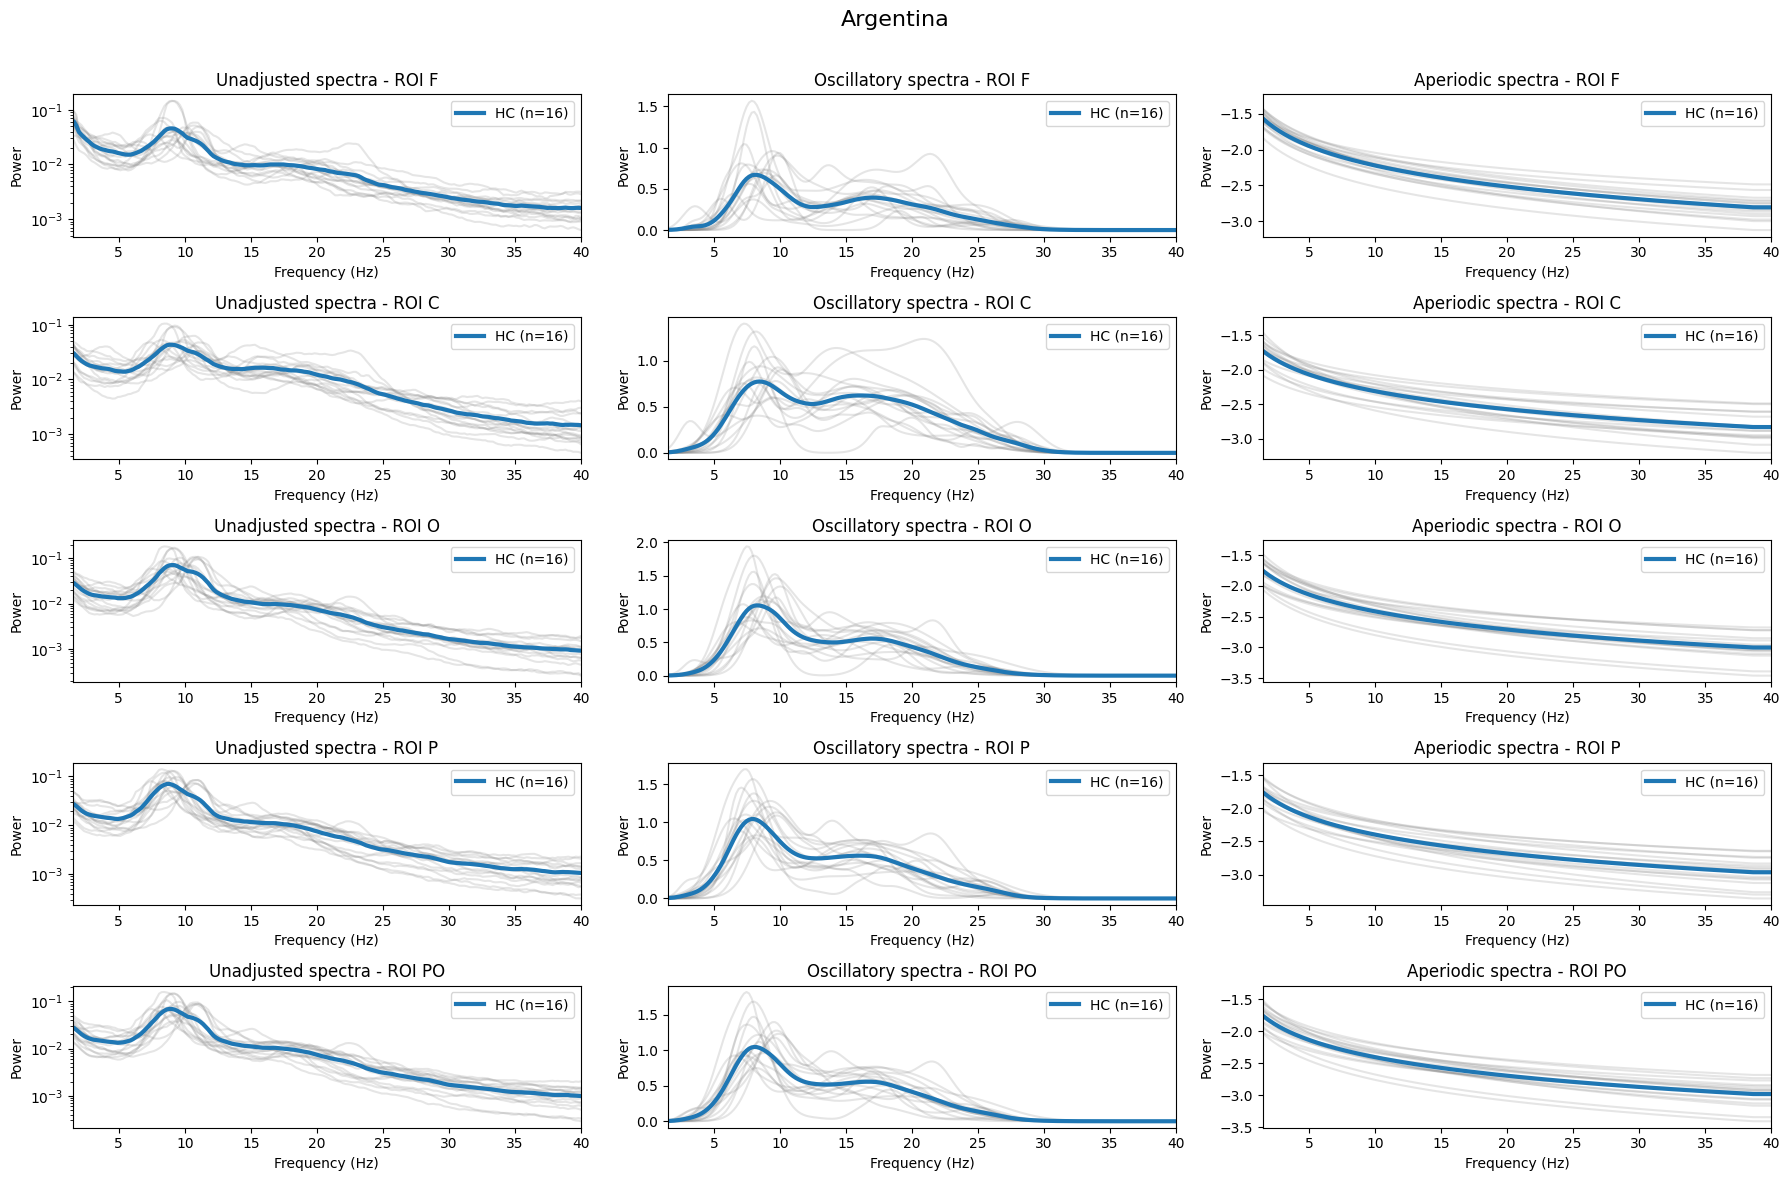

Generando figura para: Chile
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12
HC 12


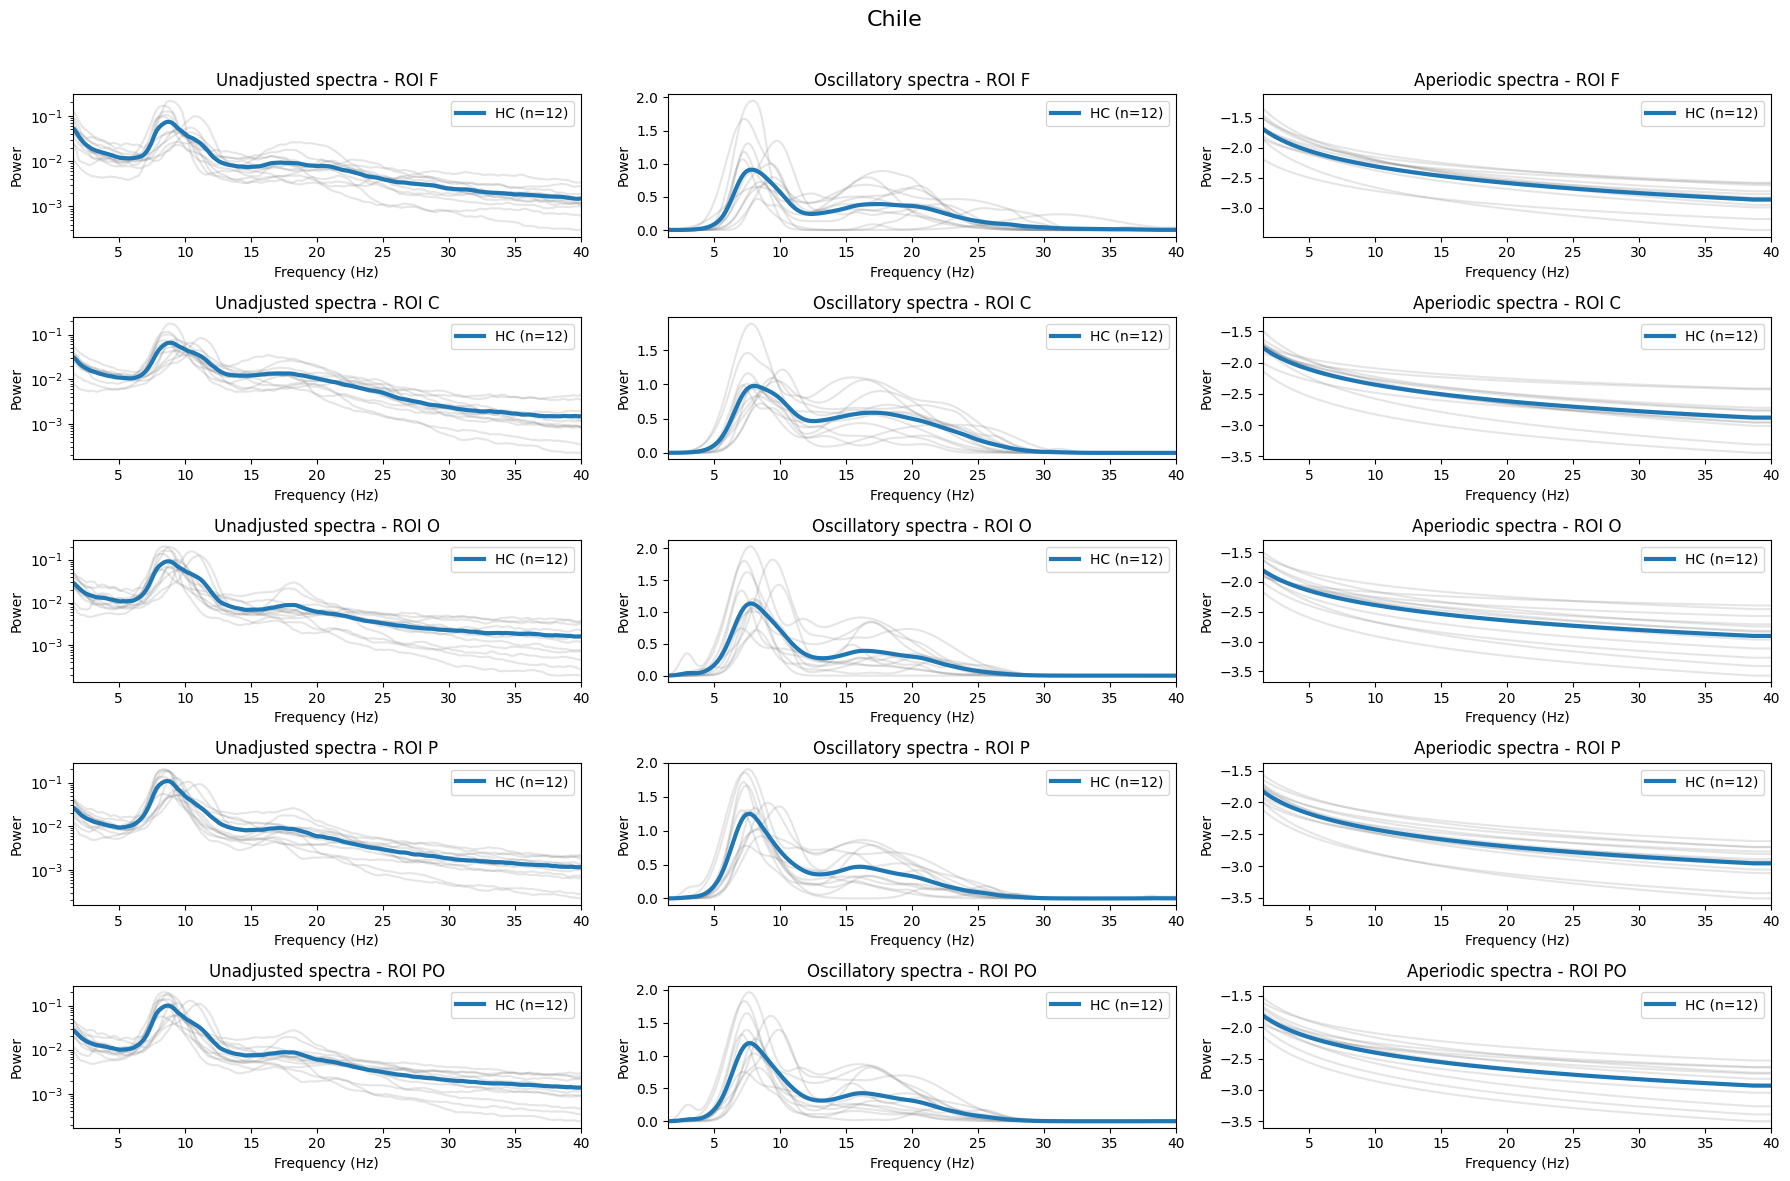

Generando figura para: Cuba
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225
HC 225


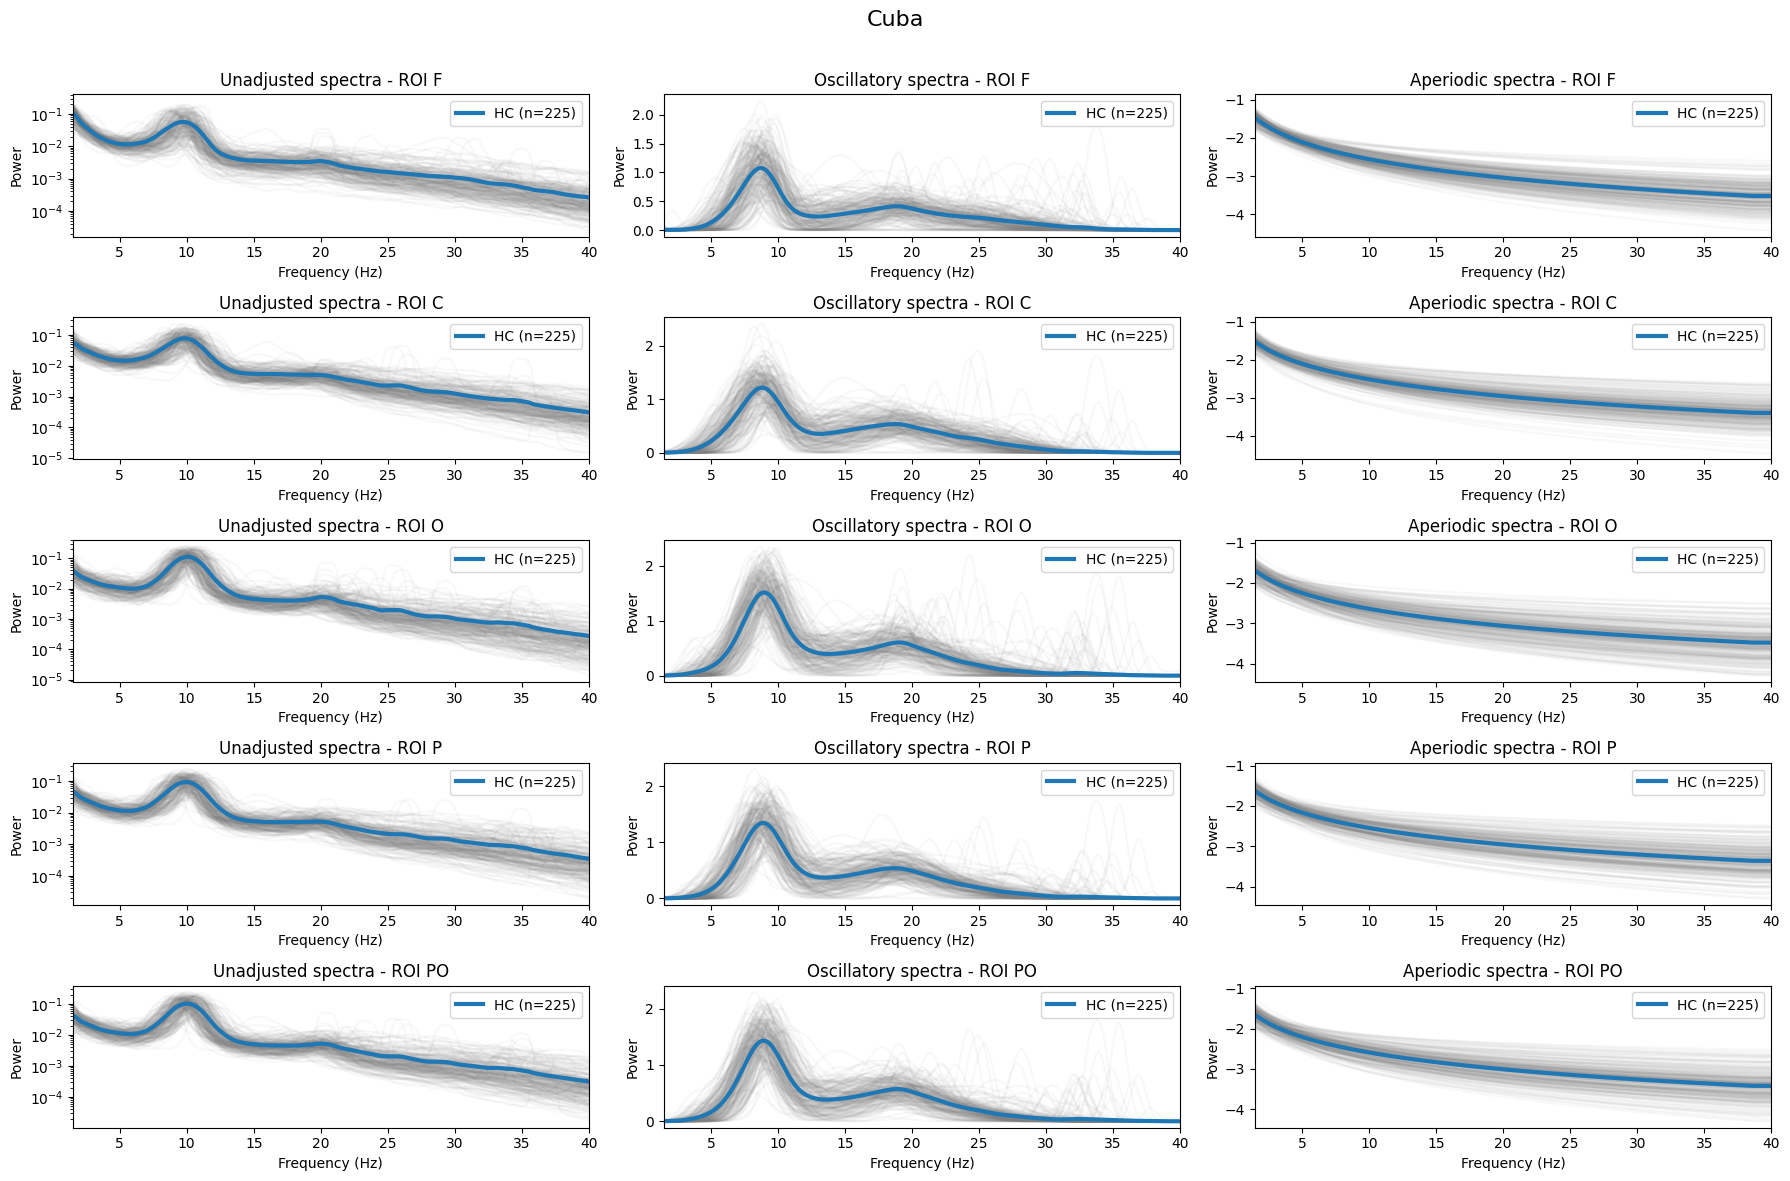

Generando figura para: Medellin_ld
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2
HC 38
MCI 2


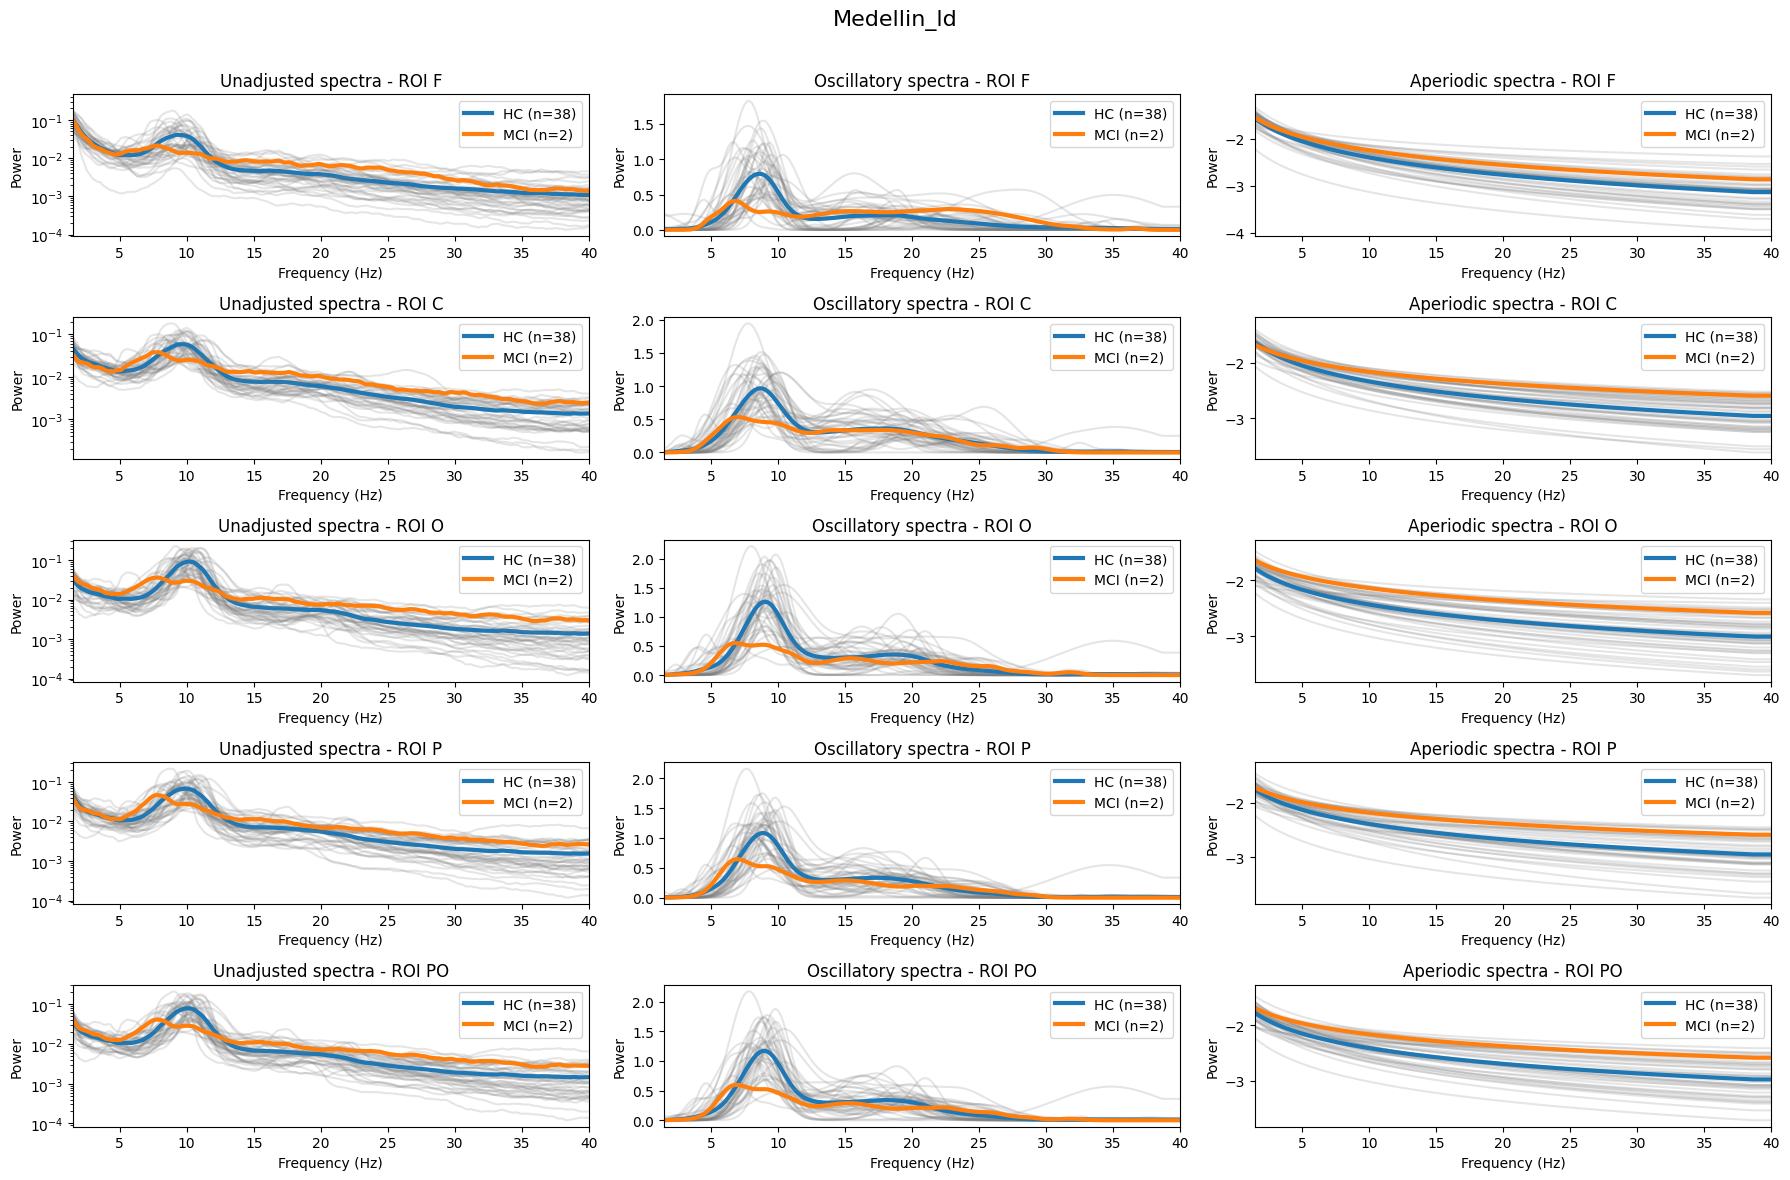

Generando figura para: Medellin_hd
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5
HC 44
MCI 5


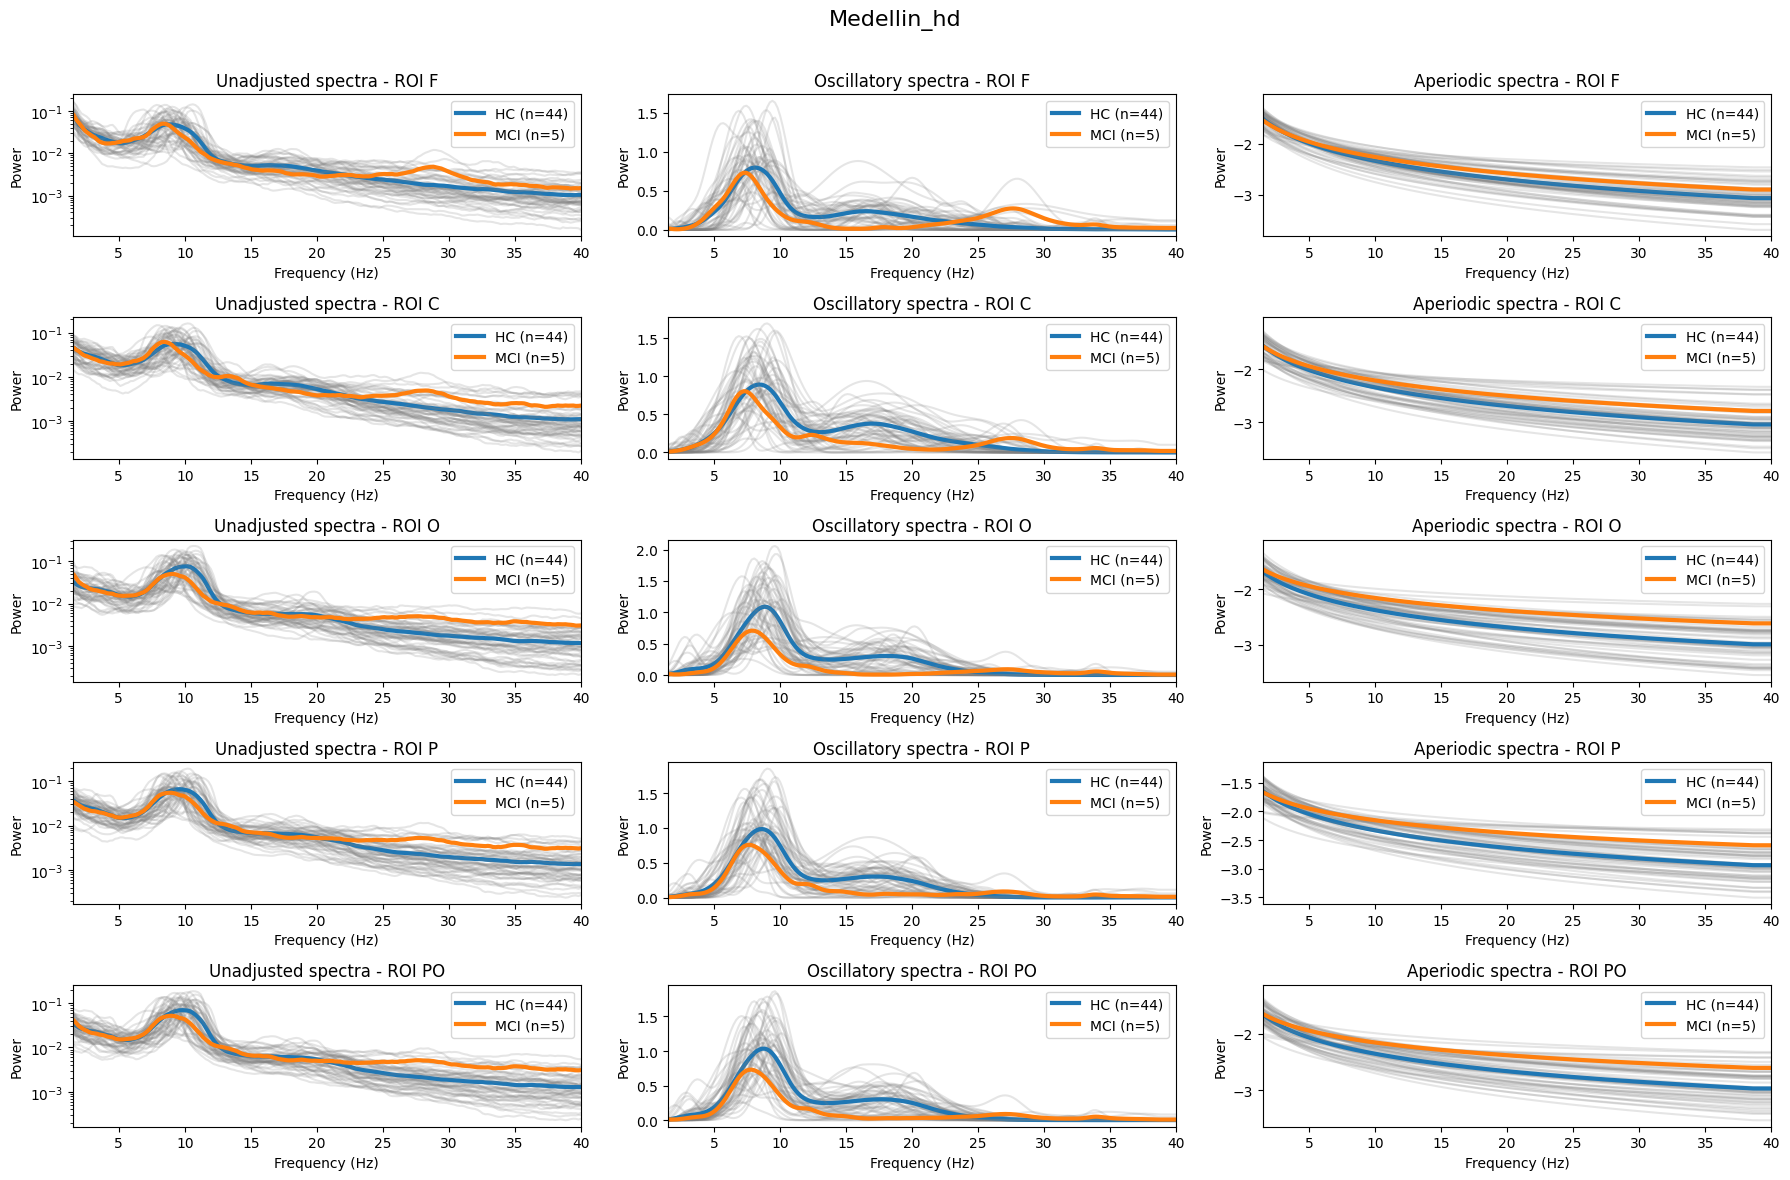

Generando figura para: Dortmund
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311
HC 311


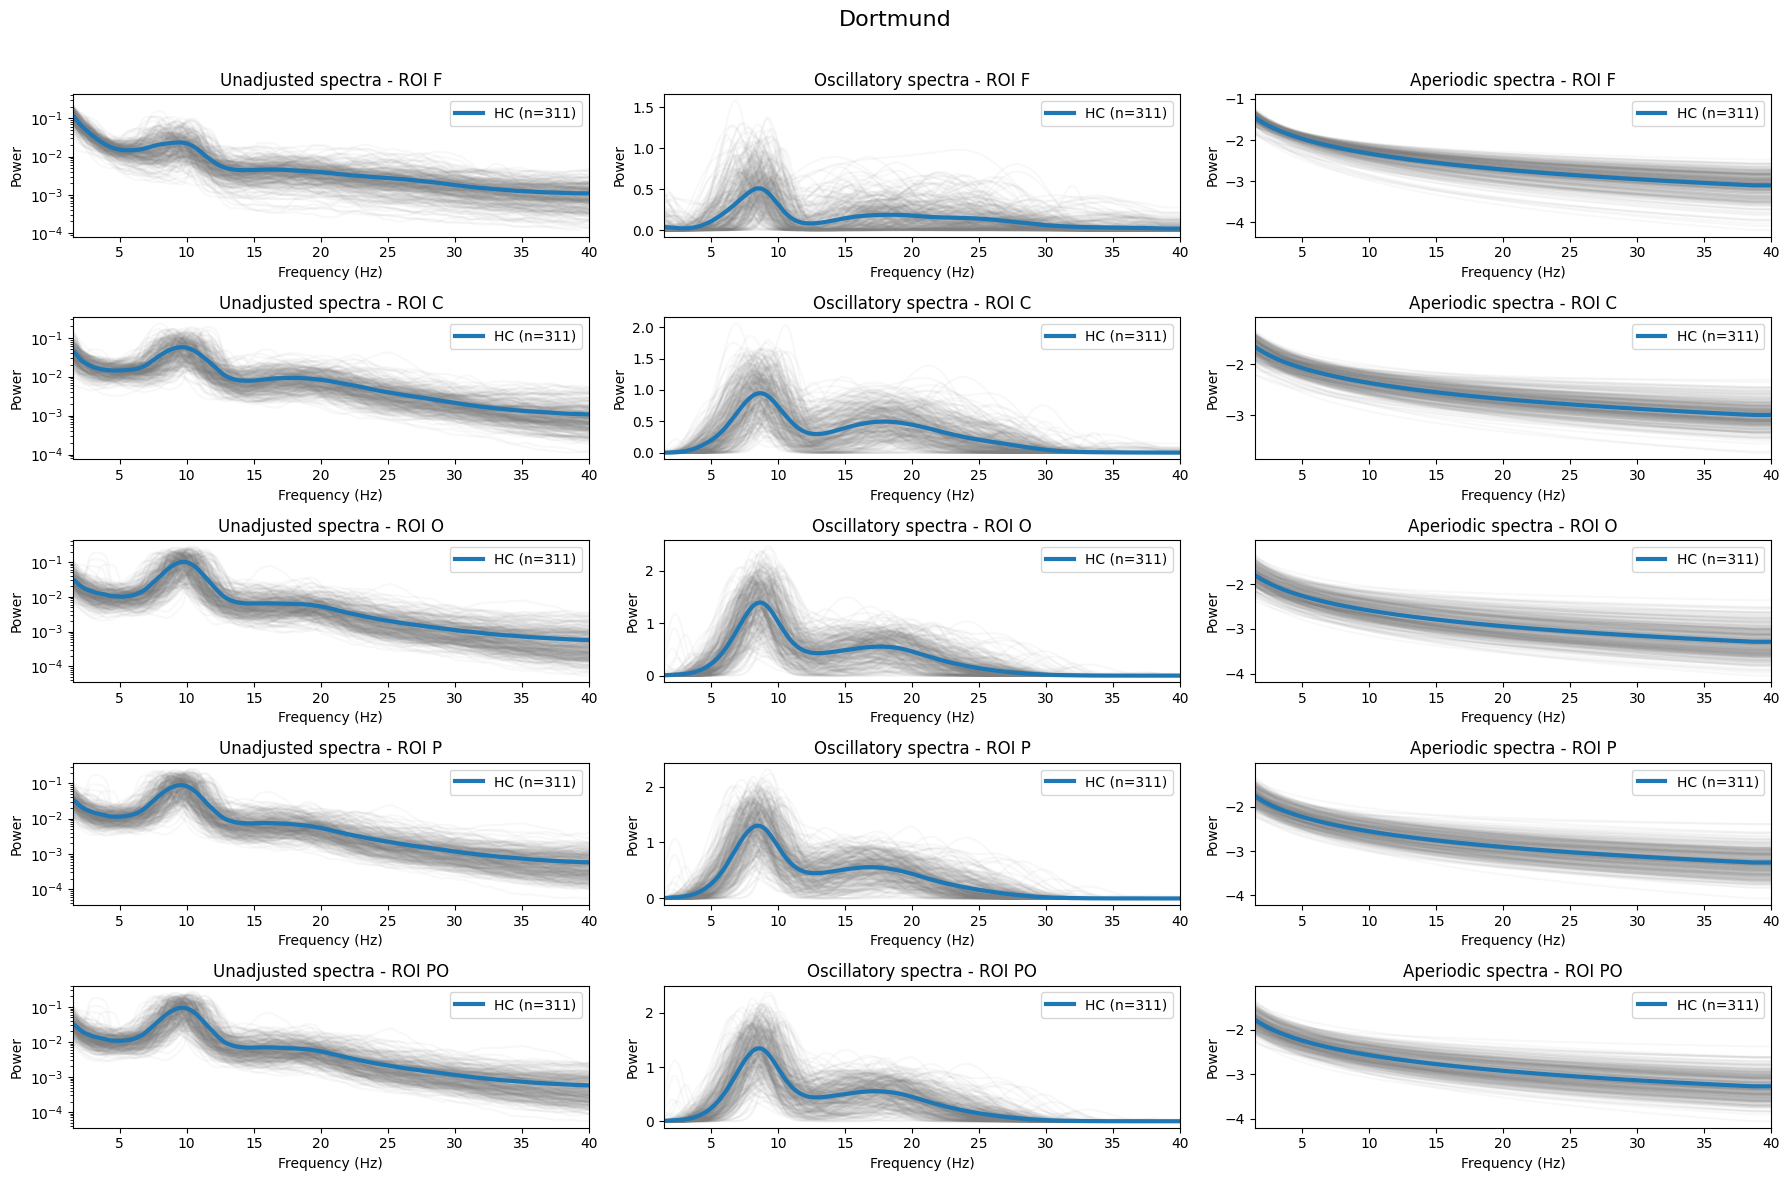

Generando figura para: Seoul
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333
MCI 273
HC 333


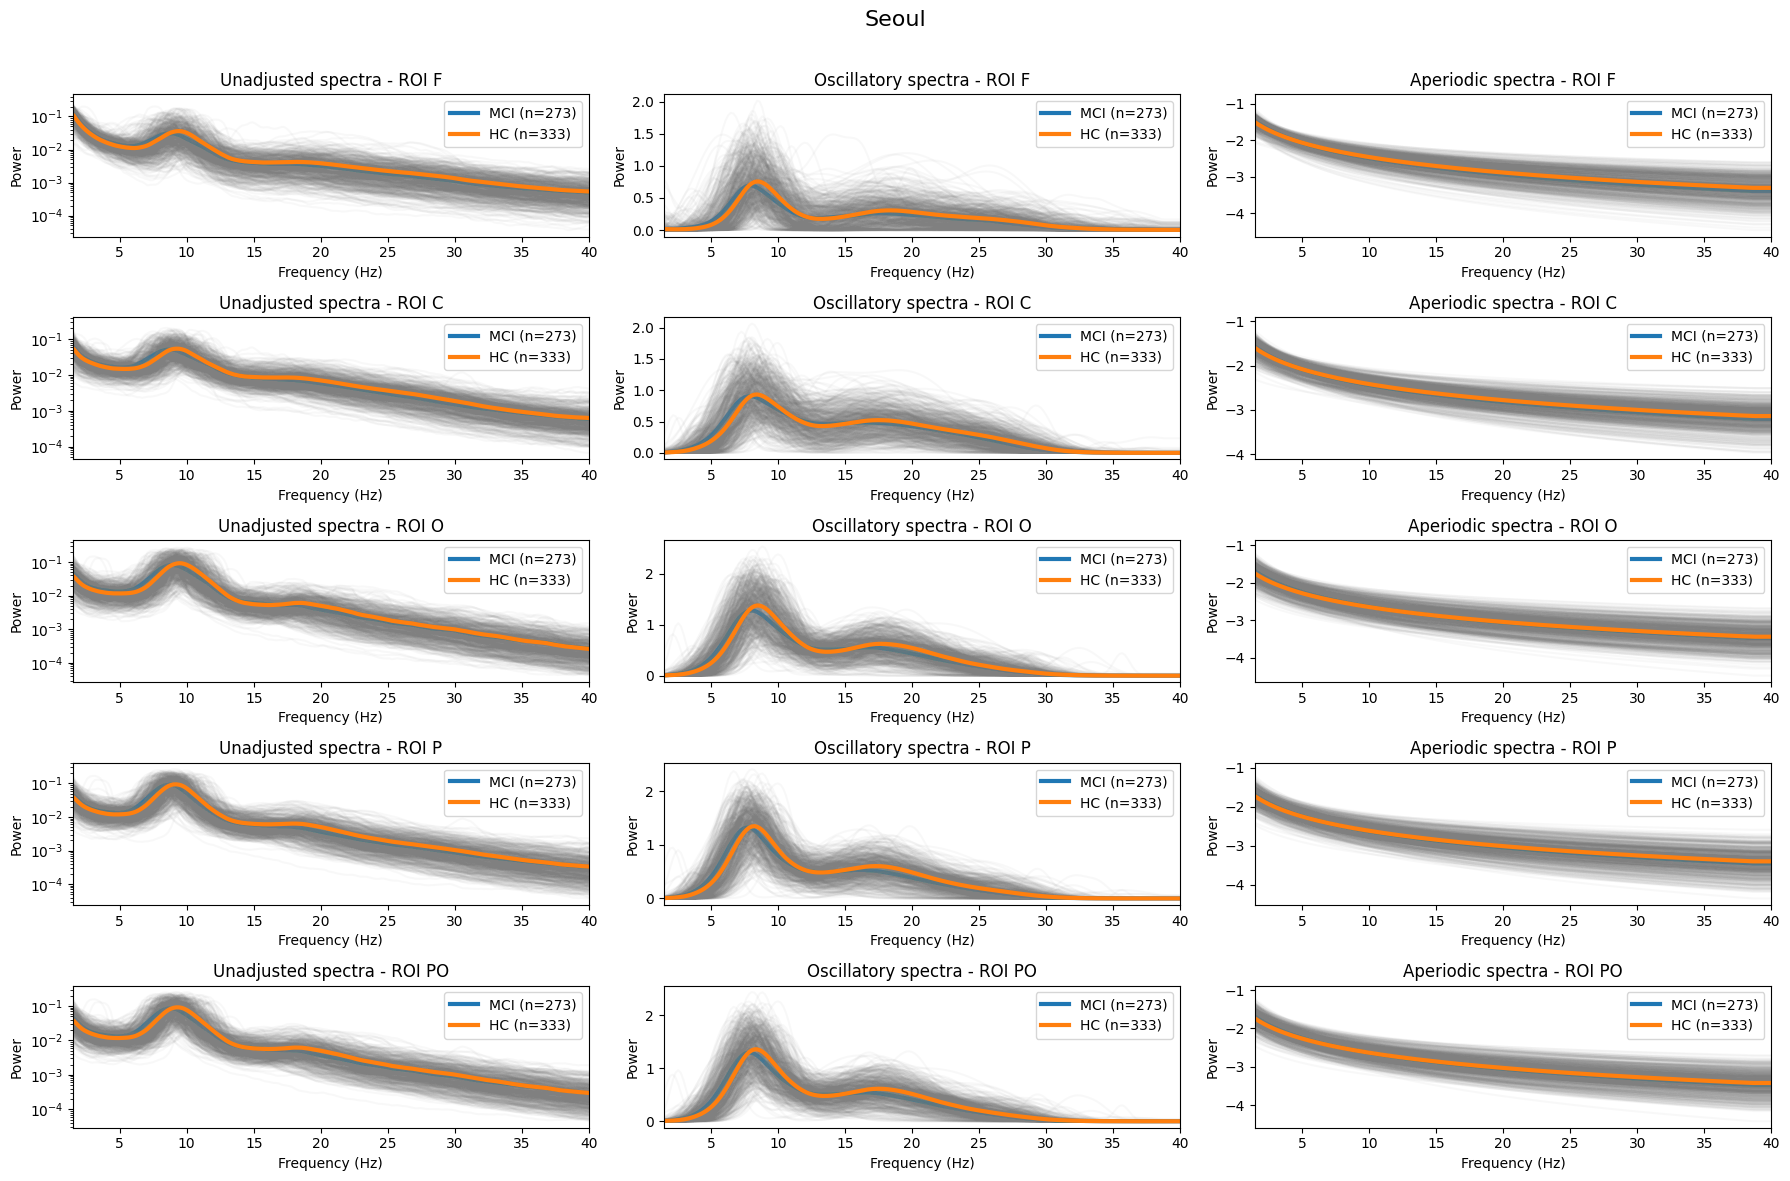

Generando figura para: Oslo
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92
HC 92


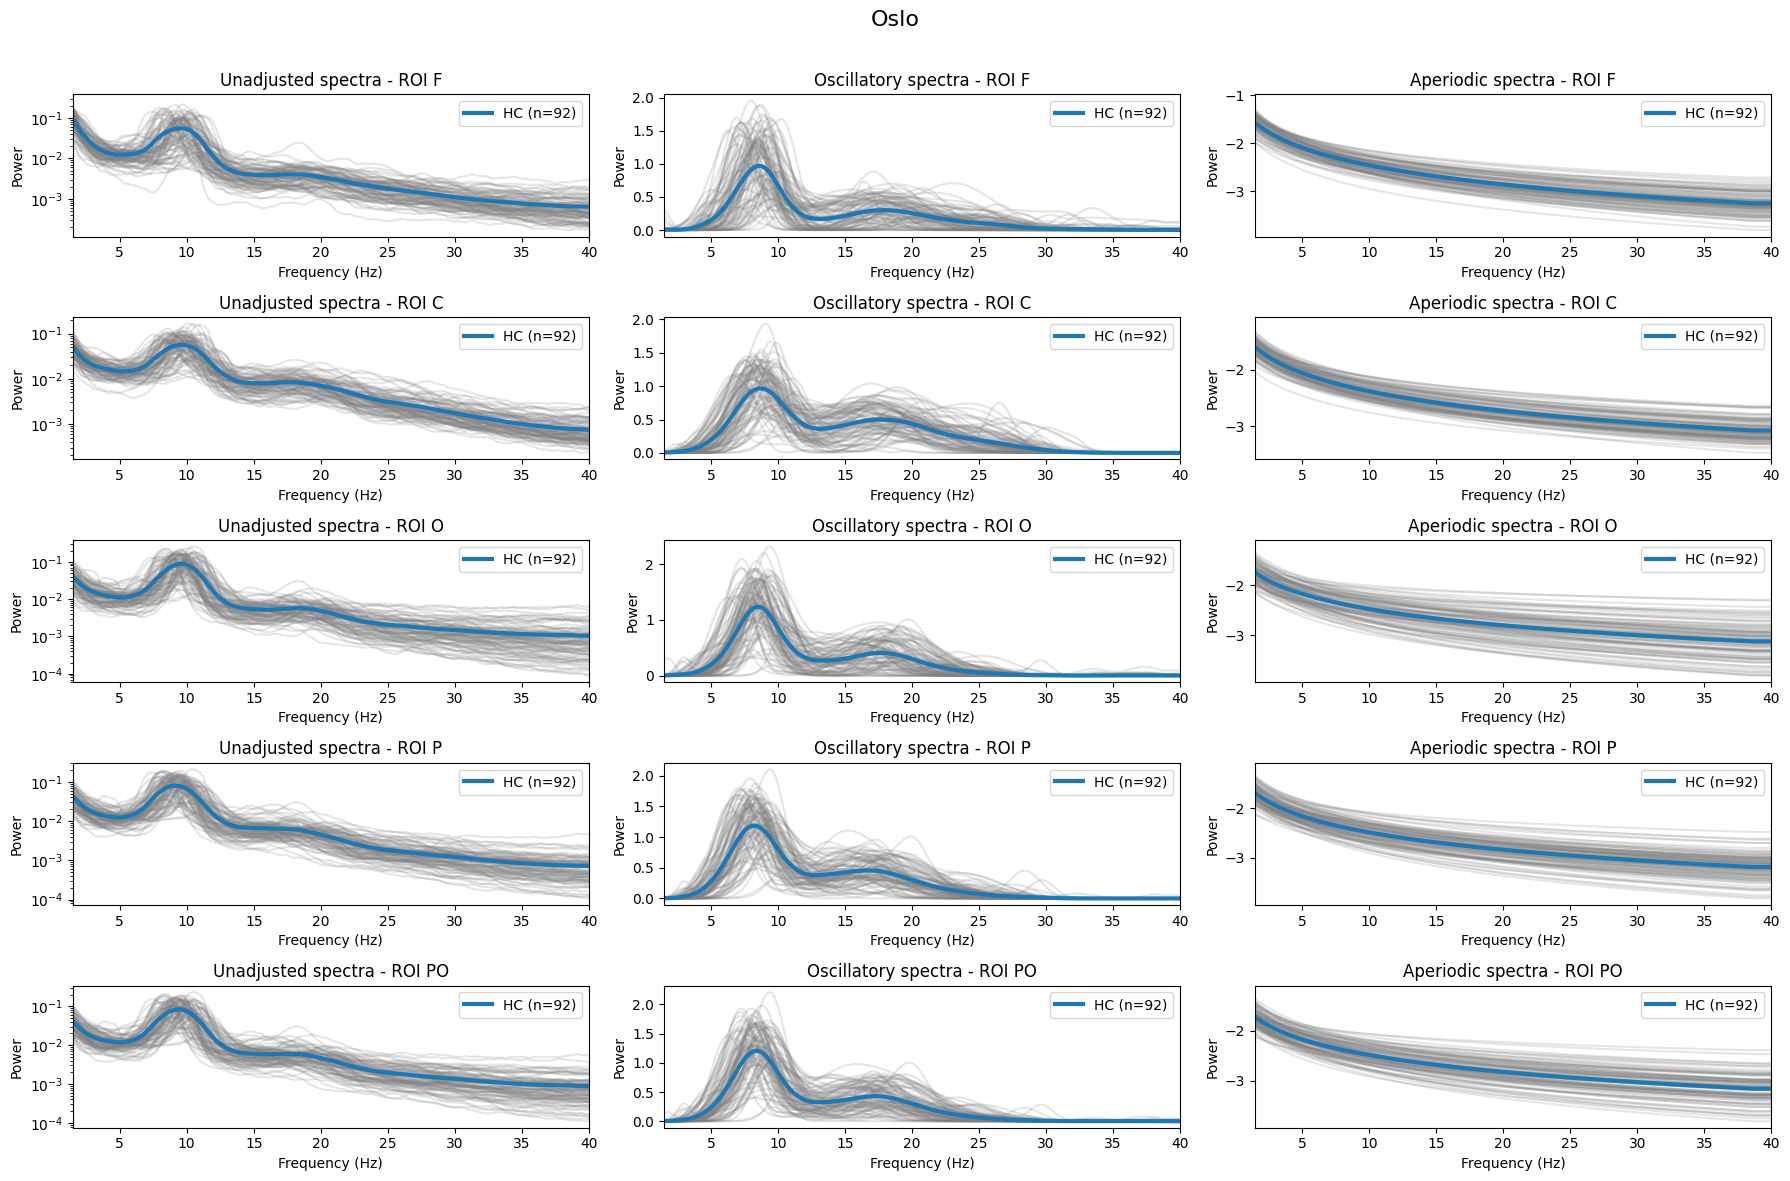

Generando figura para: Poland
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45
HC 45


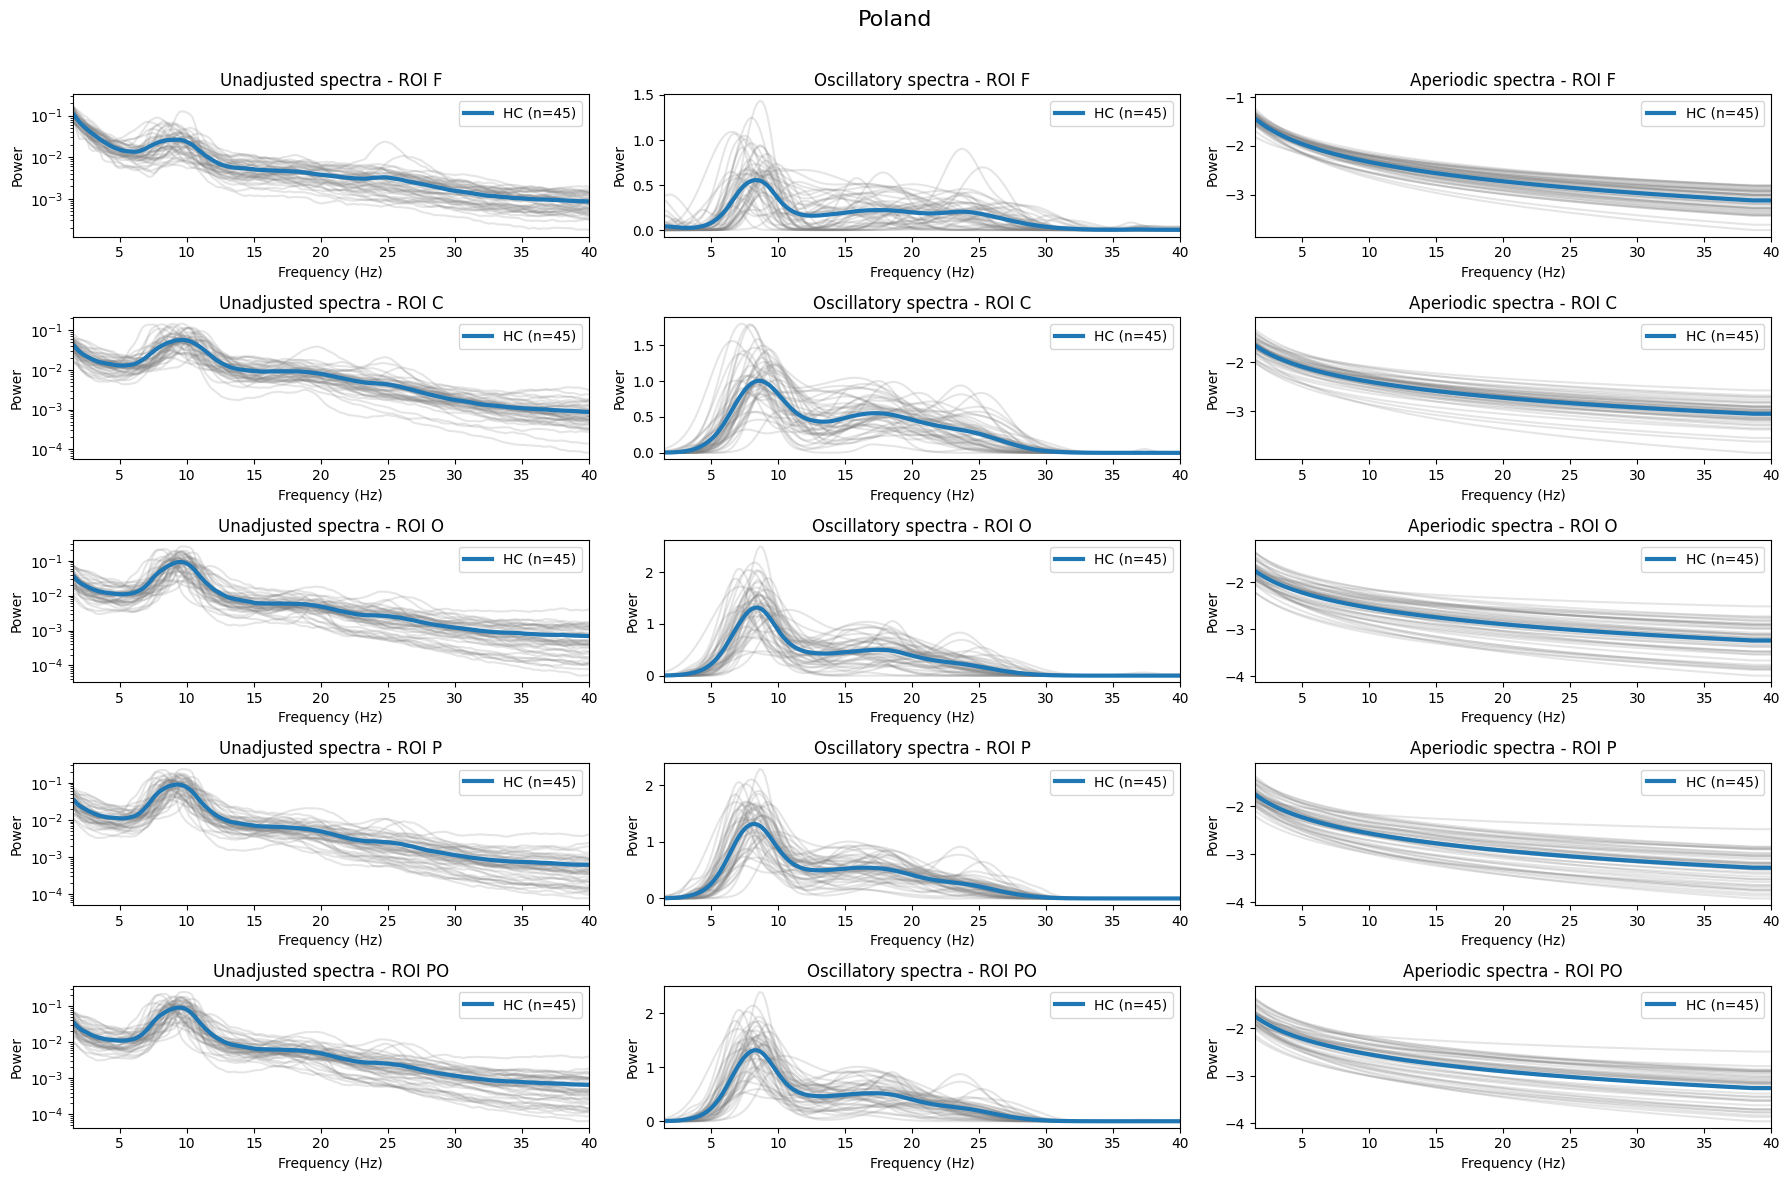

Generando figura para: Greece
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3
HC 3


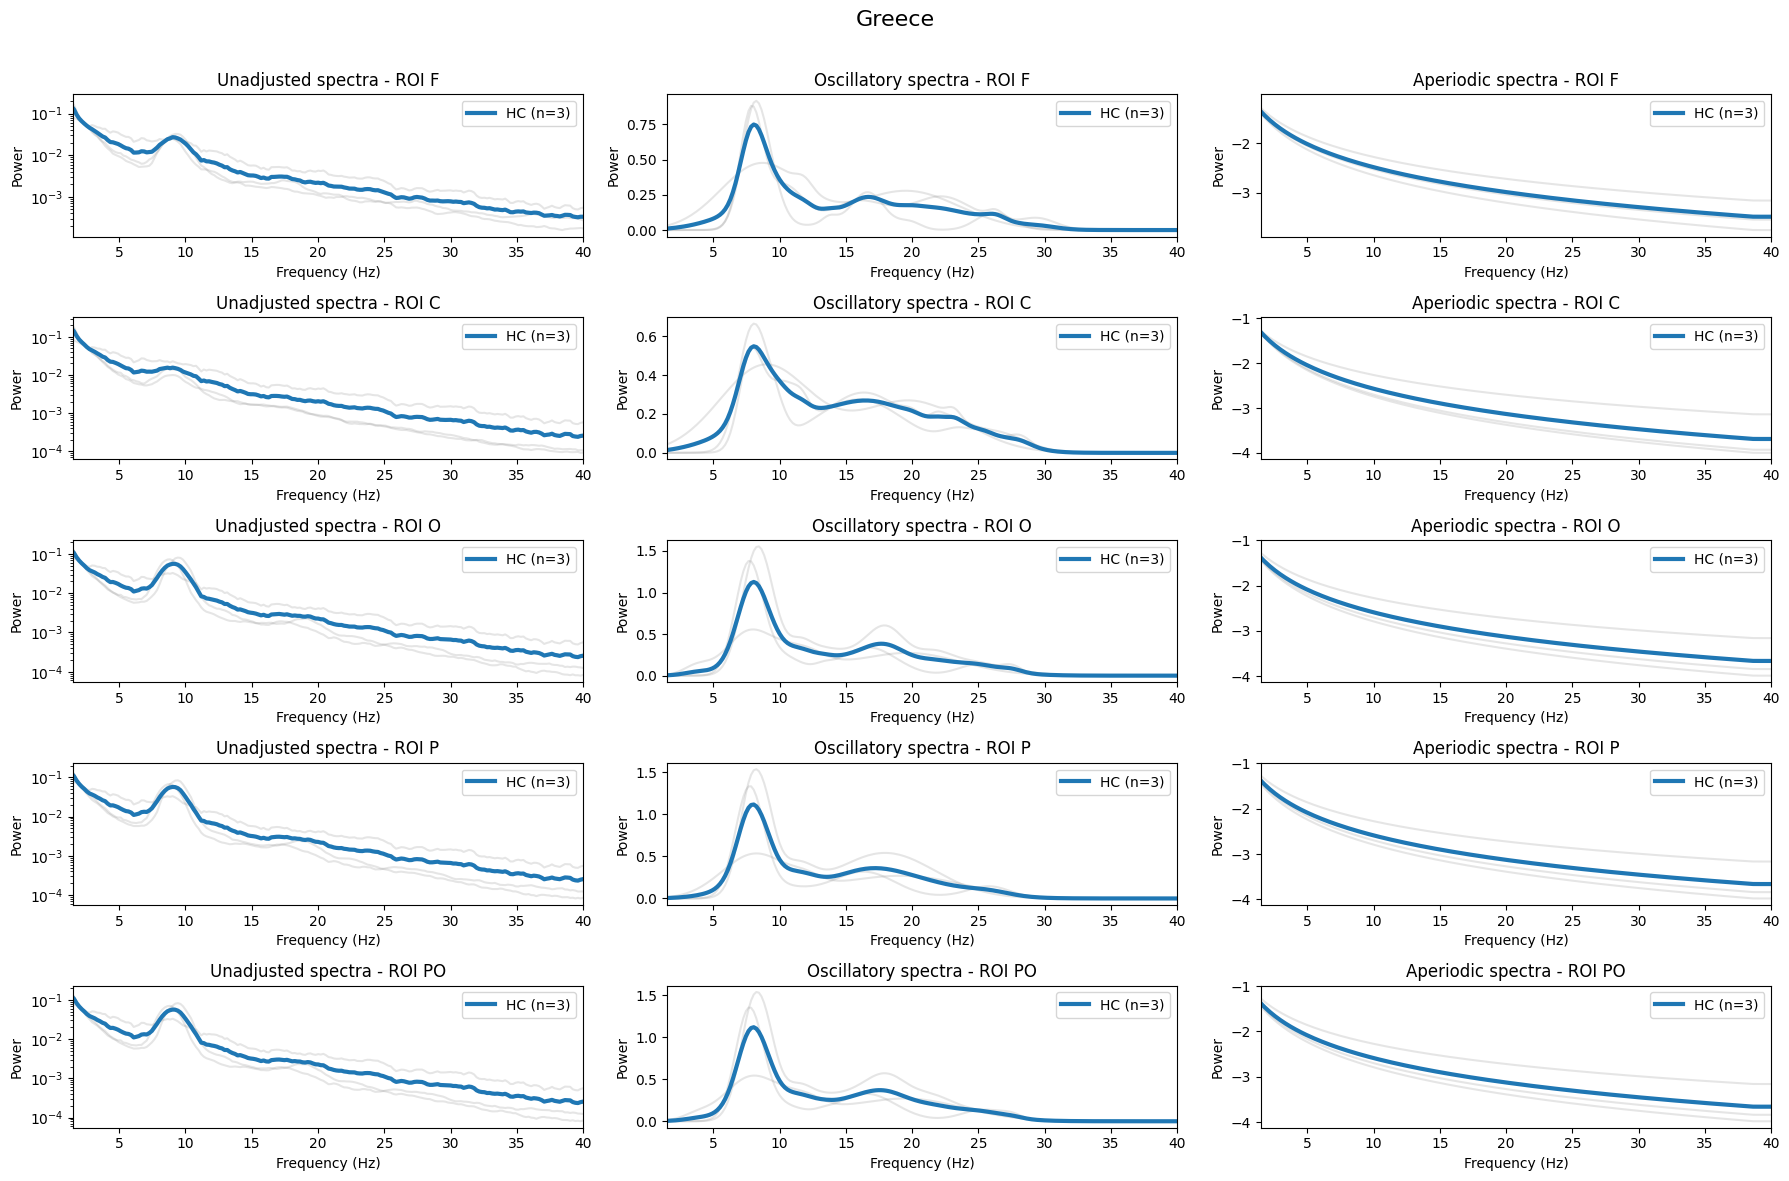

Generando figura para: Madrid
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14
MCI 24
HC 14


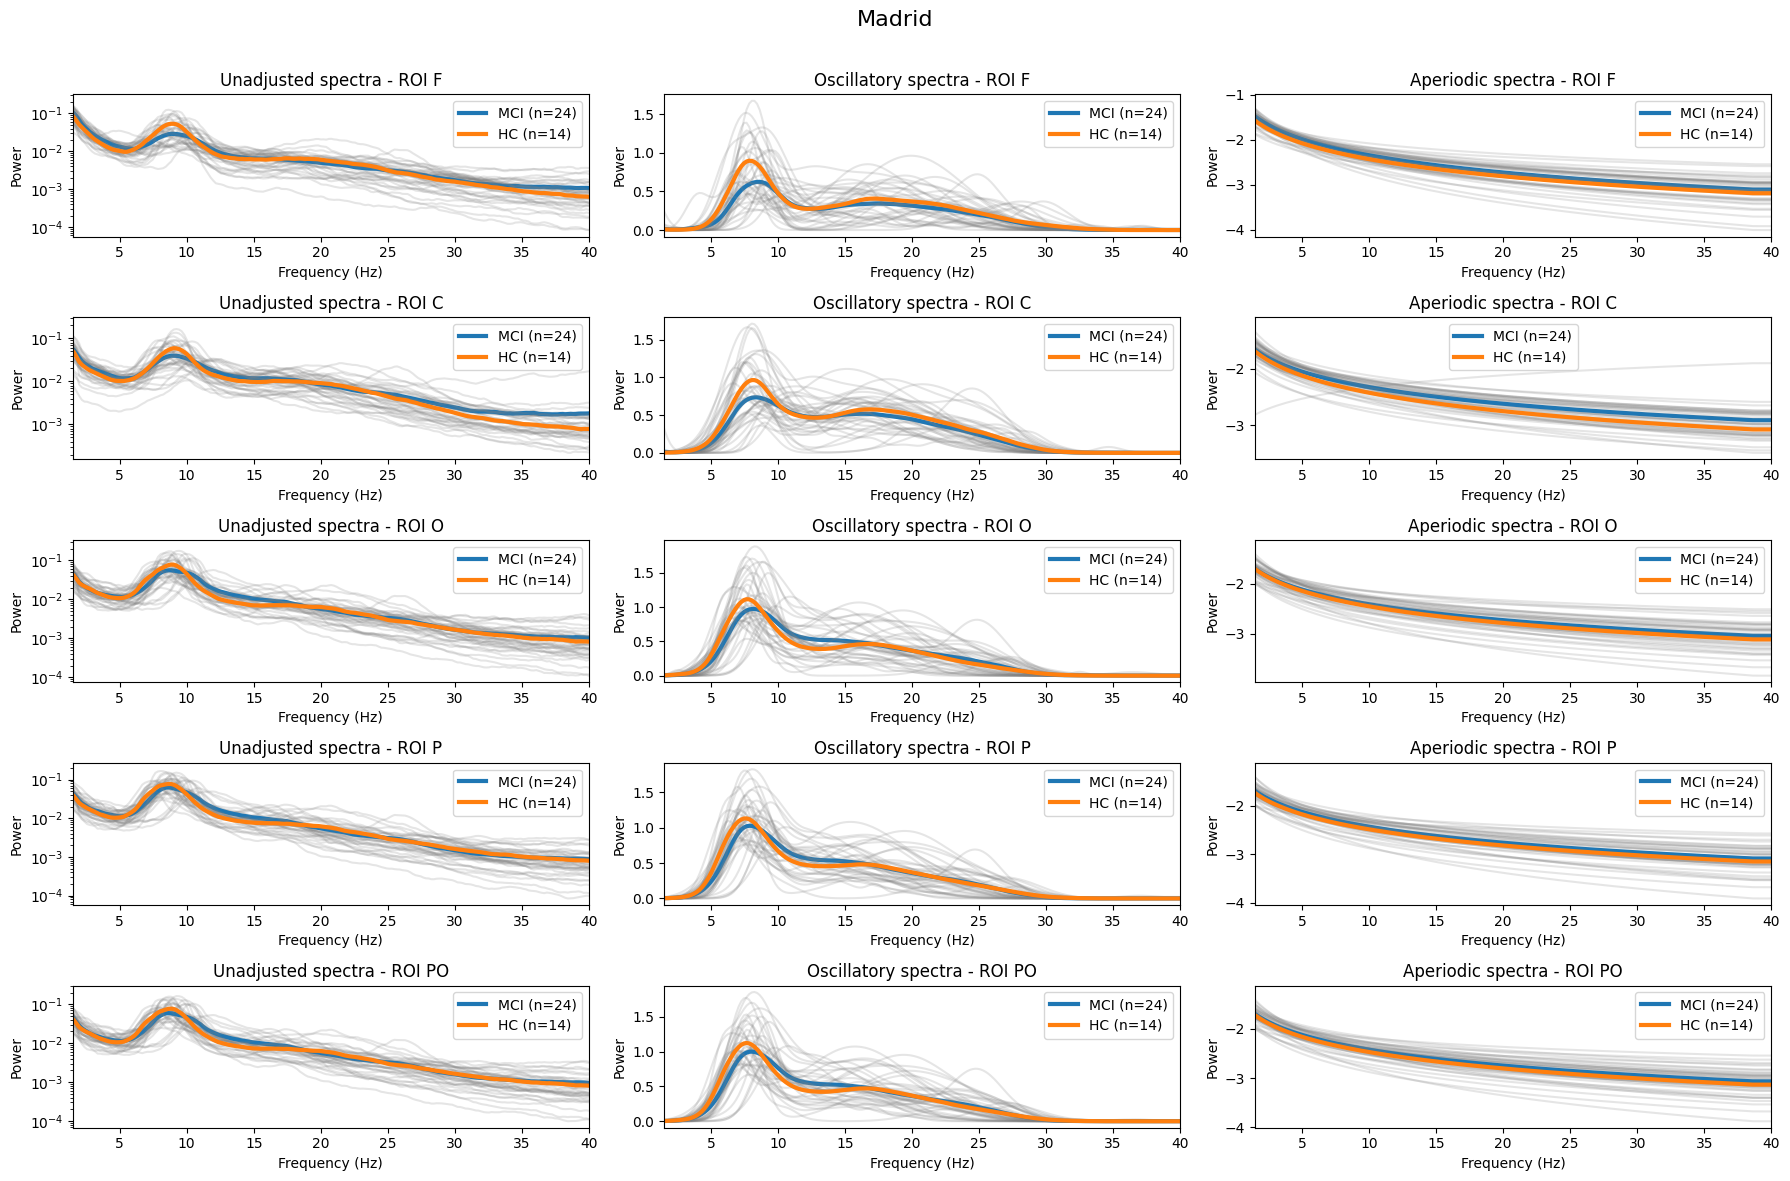

In [26]:
for db_name in filtered_IAFs_database.SITE.unique():
    data = filtered_IAFs_database[filtered_IAFs_database['SITE'] == db_name]
    plot_component_grid_by_group_roi(data, db_name)


In [27]:
def plot_average_spectrum_no_sites(data, freqs_ref, component, component_name, roi_name, electrodes_in_roi, ax):
    """
    Gráfica el promedio del componente para una ROI específica,
    sin distinguir por sitio, pero diferenciando correctamente sujetos que pertenecen a diferentes sitios.
    """
    print(data['group'].unique())
    data = data[data['group'].isin(['HC', 'MCI'])]
    groups = data['group'].unique()
    
    # PREPARACIÓN: Crear ID compuesto sujeto+sitio
    data = data.copy()
    data['subject_site'] = data['subject'].astype(str) + '_' + data['SITE'].astype(str)
    
    for group in groups:
        group_data = data[data['group'] == group]
        subjects = group_data['subject_site'].unique()
        all_group_data = []
        print(f"{group}: {len(subjects)} sujetos únicos considerando SITE")

        for subject_site in subjects:
            # Filtrar por subject+site
            subject_data = group_data[group_data['subject_site'] == subject_site]
            subject_roi_data = []

            for electrode in electrodes_in_roi:
                electrode_data = subject_data[subject_data['Sensors'] == electrode]
                if not electrode_data.empty:
                    freqs = electrode_data['freqs'].values[0]
                    comp_data = electrode_data[component].values[0]
                    interpolated = np.interp(freqs_ref, freqs[:len(comp_data)], comp_data)
                    subject_roi_data.append(interpolated)

            if subject_roi_data:
                mean_roi_subject = np.mean(subject_roi_data, axis=0)
                all_group_data.append(mean_roi_subject)

        if all_group_data:
            average_group_data = np.mean(all_group_data, axis=0)

            ax.plot(freqs_ref, average_group_data, label=f'{group} (n={len(all_group_data)})', linewidth=3)
    
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power')
    ax.set_title(f'{component_name} - {roi_name}')
    ax.set_xlim([1.5, 40])
    if component == 'psd':
        ax.set_yscale('log')
    ax.grid(False)
    ax.legend()


def plot_component_grid_merged_sites(data):
    """
    Gráfica PSD, Oscillatory Fit y Aperiodic Fit por ROI (promediando canales),
    sin distinguir por sitio. Solo diferencia por grupo (HC vs MCI).
    """
    components = [
        ('psd', 'Unadjusted spectra'),
        ('oscilatory_psd', 'Oscillatory spectra'),
        ('aperiodic_comp', 'Aperiodic spectra')
    ]
    freqs_ref = np.linspace(1, 40, 200)

    rois = {
        'ROI F': ['FP1', 'FP2'],
        'ROI C': ['C3', 'C4'],
        'ROI O': ['O1', 'O2'],
        'ROI P': ['P7', 'P8'],
        'ROI PO': ['O1', 'O2', 'P7', 'P8']
    }

    fig, axes = plt.subplots(len(rois), len(components), figsize=(18, 12))
    axes = axes.reshape(len(rois), len(components))

    print("Generando figura unificada (sin distinción por sitio)...")
    for row_idx, (roi_name, roi_channels) in enumerate(rois.items()):
        for col_idx, (component, component_name) in enumerate(components):
            ax = axes[row_idx, col_idx]
            plot_average_spectrum_no_sites(data, freqs_ref, component, component_name, roi_name, roi_channels, ax)

    fig.suptitle('Spectrum Comparison (HC vs MCI)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(rf'{path_common}\Spectrum_AllSitesCombined.pdf',
                dpi=600, format='pdf', bbox_inches='tight', transparent=True)
    plt.show()


Generando figura unificada (sin distinción por sitio)...
['HC' 'MCI' 'ACr' 'SAN' 'DTA' 'AD' 'PD' 'VD' 'A']
HC: 1133 sujetos únicos considerando SITE
MCI: 304 sujetos únicos considerando SITE
['HC' 'MCI' 'ACr' 'SAN' 'DTA' 'AD' 'PD' 'VD' 'A']
HC: 1133 sujetos únicos considerando SITE
MCI: 304 sujetos únicos considerando SITE
['HC' 'MCI' 'ACr' 'SAN' 'DTA' 'AD' 'PD' 'VD' 'A']
HC: 1133 sujetos únicos considerando SITE
MCI: 304 sujetos únicos considerando SITE
['HC' 'MCI' 'ACr' 'SAN' 'DTA' 'AD' 'PD' 'VD' 'A']
HC: 1133 sujetos únicos considerando SITE
MCI: 304 sujetos únicos considerando SITE
['HC' 'MCI' 'ACr' 'SAN' 'DTA' 'AD' 'PD' 'VD' 'A']
HC: 1133 sujetos únicos considerando SITE
MCI: 304 sujetos únicos considerando SITE
['HC' 'MCI' 'ACr' 'SAN' 'DTA' 'AD' 'PD' 'VD' 'A']
HC: 1133 sujetos únicos considerando SITE
MCI: 304 sujetos únicos considerando SITE
['HC' 'MCI' 'ACr' 'SAN' 'DTA' 'AD' 'PD' 'VD' 'A']
HC: 1133 sujetos únicos considerando SITE
MCI: 304 sujetos únicos considerando SITE
['HC'

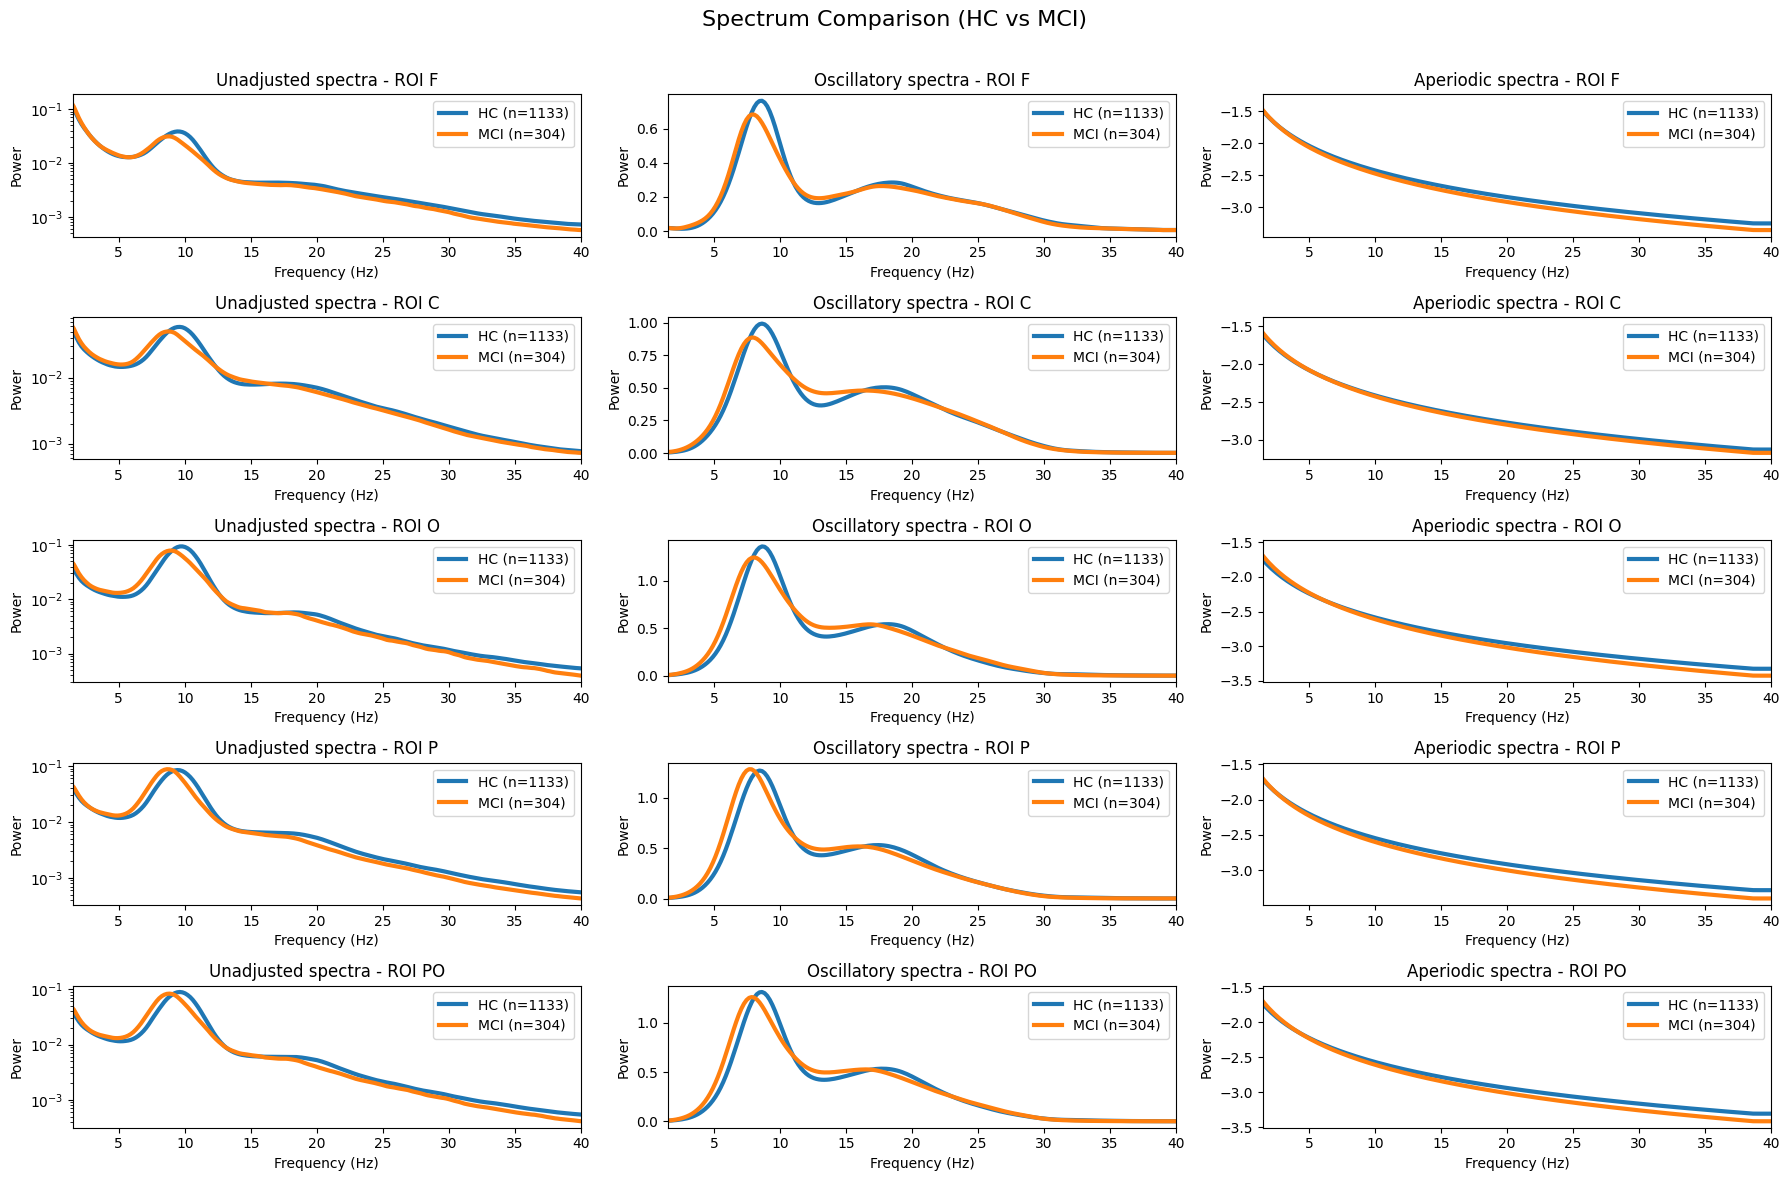

In [28]:
plot_component_grid_merged_sites(filtered_IAFs_database)

Merge database with covariable

In [29]:
import sys
sys.path.append(r'D:\flujo_portables\portables')
from run_config_params.DATASET import Dortmund, AR, CL, CHBMP, PORTABLES_CE, BIOMARCADORES, CAUEEG_CONCAT, SRM, Poland, GREECE,Madrid_c3n

PATH_DEM = {
    'Dortmund': { 'dem': Dortmund['demographic'], 'variables_dem': ['sex']},#'laterality'
    'Argentina': {'dem': AR['demographic'],'variables_dem':['sex','education', 'laterality','zscore_cognitive']},
    'Chile': {'dem': CL['demographic'],'variables_dem':['sex','education', 'laterality','zscore_cognitive']},
    'Cuba': {'dem': CHBMP['demographic'], 'variables_dem':['sex']},#'zscore_cognitive'
    'Medellin_ld': {'dem': PORTABLES_CE['demographic'],'variables_dem':['sex','education','zscore_cognitive']},
    'Medellin_hd': {'dem': BIOMARCADORES['demographic'],'variables_dem':['sex', 'education','zscore_cognitive']},
    'Seoul': {'dem':CAUEEG_CONCAT['demographic']},
    'Oslo': {'dem': SRM['demographic'],'variables_dem':[ 'sex','zscore_cognitive']},
    'Poland': {'dem': Poland['demographic'],'variables_dem':['sex', 'education','zscore_cognitive']},
    'Greece': {'dem': GREECE['demographic'],'variables_dem':['sex','zscore_cognitive']},
    'Madrid': {'dem': Madrid_c3n['demographic'],'variables_dem':['sex', 'zscore_cognitive']}
}

In [30]:
path_save = rf'{path_common}\AIF_Babiloni'
IAF_FOOOF_Dortmund= IAF2columns(filtered_IAFs_database,'Dortmund', 
                                path_save= path_save, 
                                path_demographics= PATH_DEM['Dortmund']['dem'],
                                variables_dem= PATH_DEM['Dortmund']['variables_dem'],
                                drop_columns =['session1', 'late_ses1', 'session2',
                                               'late_ses2', 'laterality'])
IAF_FOOOF_AR= IAF2columns(filtered_IAFs_database,'Argentina',
                        path_save= path_save, 
                        path_demographics= PATH_DEM['Argentina']['dem'],
                        variables_dem= PATH_DEM['Argentina']['variables_dem'],
                        drop_columns =['diagnosis','MoCA_total', 'moca_visuospatial', 'moca_recog', 'moca_attention',
                        'moca_language', 'moca_abstraction', 'moca_memory', 'moca_orientation',
                        'ifs_total_score', 'ifs_motor_series', 'ifs_conflicting_instructions',
                        'ifs_motor_inhibition', 'ifs_digits', 'ifs_months', 'ifs_visual_wm',
                        'ifs_proverb', 'ifs_verbal_inhibition', 'mini_sea_fer', 'mini_sea_tom',
                        'ifs_total_score_zscore'])
IAF_FOOOF_CL= IAF2columns(filtered_IAFs_database, 'Chile',
                        path_save= path_save, 
                        path_demographics= PATH_DEM['Chile']['dem'],
                        variables_dem= PATH_DEM['Chile']['variables_dem'],
                        drop_columns =['diagnosis', 'MoCA_total', 'moca_visuospatial', 'moca_recog', 'moca_attention',
                        'moca_language', 'moca_abstraction', 'moca_memory', 'moca_orientation',
                        'ifs_total_score', 'ifs_motor_series', 'ifs_conflicting_instructions',
                        'ifs_motor_inhibition', 'ifs_digits', 'ifs_months', 'ifs_visual_wm',
                        'ifs_proverb', 'ifs_verbal_inhibition', 'mini_sea_fer', 'mini_sea_tom',
                        'ifs_total_score_zscore']
                        )
IAF_FOOOF_CHBMP= IAF2columns(filtered_IAFs_database,'Cuba',
                        path_save= path_save,
                        path_demographics= PATH_DEM['Cuba']['dem'],
                        variables_dem= PATH_DEM['Cuba']['variables_dem'],
                        drop_columns=['Weight lb', 'Education Level ',  'MMSE_total',
                        'Orientation_to_Time', 'Orientation_to_place', 'Retention',
                        'Attention_calculations', 'recall', 'Language'])
IAF_FOOOF_Medellin_ld= IAF2columns(filtered_IAFs_database, 'Medellin_ld',
                                path_save= path_save,
                                path_demographics= PATH_DEM['Medellin_ld']['dem'],
                                variables_dem= PATH_DEM['Medellin_ld']['variables_dem'],
                                drop_columns=['MMSE_total', 'MoCA_total', 'MoCA_total_zscore'])
IAF_FOOOF_Medellin_hd= IAF2columns(filtered_IAFs_database,'Medellin_hd', 
                                   path_save= path_save, 
                                   path_demographics= PATH_DEM['Medellin_hd']['dem'],
                                   variables_dem= PATH_DEM['Medellin_hd']['variables_dem'],
                                   drop_columns=['MMSE_total', 'FAS_F', 'FAS_A', 'FAS_S',
                                                 'visit'])
IAF_FOOOF_CAUEEG= IAF2columns(filtered_IAFs_database,'Seoul',
                              path_save= path_save, 
                              path_demographics= PATH_DEM['Seoul']['dem'], 
                              variables_dem= None,
                              drop_columns=['level_1', 'level_2'])
IAF_FOOOF_SRM= IAF2columns(filtered_IAFs_database, 'Oslo',
                        path_save= path_save, 
                        path_demographics= PATH_DEM['Oslo']['dem'],
                        variables_dem= PATH_DEM['Oslo']['variables_dem'],
                        drop_columns=[ 'ravlt_1', 'ravlt_5', 'ravlt_tot', 'ravlt_imm',
                        'ravlt_del', 'ravlt_rec', 'ravlt_fp', 'ds_forw', 'ds_back', 'ds_seq',
                        'ds_tot', 'tmt_2', 'tmt_3', 'tmt_4', 'cw_1', 'cw_2', 'cw_3', 'cw_4',
                        'vf_1', 'vf_2', 'vf_3'])
IAF_FOOOF_Poland = IAF2columns(filtered_IAFs_database,'Poland',
                               path_save= path_save, 
                               path_demographics= PATH_DEM['Poland']['dem'],
                               variables_dem= PATH_DEM['Poland']['variables_dem'],
                               drop_columns=['CVLT_score_1_5']#education
                               )
IAF_FOOOF_greece = IAF2columns(filtered_IAFs_database,'Greece',
                               path_save= path_save,
                               path_demographics= PATH_DEM['Greece']['dem'],
                               variables_dem= PATH_DEM['Greece']['variables_dem'],
                               drop_columns=['MMSE']
                               )
IAF_FOOOF_Madrid = IAF2columns(filtered_IAFs_database,'Madrid',
                               path_save= path_save,
                               path_demographics= PATH_DEM['Madrid']['dem'],
                               variables_dem= PATH_DEM['Madrid']['variables_dem'],
                               drop_columns=['MMSE_total', 'MoCA_total', 'MoCA_total_zscore']
                               )

Index(['subject', 'group', 'sex', 'age', 'SITE'], dtype='object')
Index(['subject', 'Sensors', 'group', 'freqs', 'psd', 'SITE', 'TF_original',
       'TF_below_3', 'TF_corrected', 'TF', 'IAFp', 'delta_Band', 'theta_Band',
       'BGF1_Band', 'BGF2_Band', 'BGF3_Band', 'beta_Band', 'pw_delta',
       'pw_theta', 'pw_BGF1', 'pw_BGF2', 'pw_BGF3', 'pw_beta', 'pw_ab_delta',
       'pw_ab_theta', 'pw_ab_BGF1', 'pw_ab_BGF2', 'pw_ab_BGF3', 'pw_ab_beta',
       'delta_canonic_Band', 'theta_canonic_Band', 'alpha1_canonic_Band',
       'alpha2_canonic_Band', 'beta1_canonic_Band', 'beta2_canonic_Band',
       'beta3_canonic_Band', 'gamma_canonic_Band', 'pw_canonic_delta',
       'pw_canonic_theta', 'pw_canonic_alpha1', 'pw_canonic_alpha2',
       'pw_canonic_beta1', 'pw_canonic_beta2', 'pw_canonic_beta3',
       'pw_canonic_gamma', 'pw_ab_canonic_delta', 'pw_ab_canonic_theta',
       'pw_ab_canonic_alpha1', 'pw_ab_canonic_alpha2', 'pw_ab_canonic_beta1',
       'pw_ab_canonic_beta2', 'pw_ab_canonic_

In [31]:
IAF_FOOOF_demographic = pd.concat([IAF_FOOOF_Dortmund, IAF_FOOOF_AR, IAF_FOOOF_CL, IAF_FOOOF_CHBMP, IAF_FOOOF_Medellin_ld, IAF_FOOOF_Medellin_hd, IAF_FOOOF_CAUEEG, IAF_FOOOF_SRM, IAF_FOOOF_Poland, IAF_FOOOF_greece, IAF_FOOOF_Madrid], axis=0)
renombrar_grupos = {'G2': 'HC', 'GU': 'HC', 'CTR': 'HC', 'DCL': 'MCI'}
IAF_FOOOF_demographic['group'] = IAF_FOOOF_demographic['group'].replace(renombrar_grupos)
IAF_FOOOF_demographic.dropna(subset='group', inplace=True)
merge_IAF_FOOOF= IAF_FOOOF_demographic.copy()
IAF_FOOOF_age = merge_IAF_FOOOF.loc[:, :'age'].drop(columns=['sex']).dropna()
IAF_FOOOF_age_sex = merge_IAF_FOOOF.loc[:, :'age'].dropna()
IAF_FOOOF_age_sex_cognitive = merge_IAF_FOOOF.loc[:, :'zscore_cognitive'].drop(columns= ['education','laterality'])
IAF_FOOOF_age_sex_cognitive.dropna( inplace=True)



In [32]:
IAF_FOOOF_age.columns

Index(['subject', 'group', 'SITE', 'freqs_C3', 'freqs_C4', 'freqs_FP1',
       'freqs_FP2', 'freqs_O1', 'freqs_O2', 'freqs_P7',
       ...
       'osc_pw_canonic_beta3_P8', 'osc_pw_canonic_gamma_C3',
       'osc_pw_canonic_gamma_C4', 'osc_pw_canonic_gamma_FP1',
       'osc_pw_canonic_gamma_FP2', 'osc_pw_canonic_gamma_O1',
       'osc_pw_canonic_gamma_O2', 'osc_pw_canonic_gamma_P7',
       'osc_pw_canonic_gamma_P8', 'age'],
      dtype='object', length=524)

In [33]:
IAF_FOOOF_age[IAF_FOOOF_age['group'] == 'HC'].groupby('SITE')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
SITE,,,,,,,,
Argentina,16.0,68.250000,8.559595,56.0,61.00,68.5,74.75,83.0
Chile,12.0,73.166667,4.549392,64.0,71.50,73.0,76.25,80.0
Cuba,225.0,31.871111,9.323373,18.0,25.00,31.0,37.00,68.0
Dortmund,308.0,43.314935,14.789341,20.0,29.00,43.5,56.00,70.0
Greece,3.0,66.666667,3.055050,64.0,65.00,66.0,68.00,70.0
Madrid,13.0,83.153846,6.080654,71.0,81.00,83.0,85.00,94.0
Medellin_hd,43.0,39.116279,10.858855,22.0,30.00,39.0,46.00,63.0
Medellin_ld,38.0,46.631579,15.555343,23.0,36.00,44.0,58.75,76.0
Oslo,92.0,37.663043,13.946741,17.0,27.75,35.0,47.25,71.0


In [34]:
IAF_FOOOF_age[IAF_FOOOF_age['group'] == 'MCI'].groupby('SITE')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
SITE,,,,,,,,
Madrid,24.0,79.625000,5.769579,70.0,76.0,80.0,84.0,91.0
Medellin_hd,5.0,43.600000,4.277850,38.0,43.0,43.0,44.0,50.0
Medellin_ld,2.0,53.000000,7.071068,48.0,50.5,53.0,55.5,58.0
Seoul,272.0,74.022059,7.718734,52.0,69.0,75.0,80.0,93.0


In [35]:
IAF_FOOOF_age_sex[IAF_FOOOF_age_sex['group'] == 'HC'].groupby('SITE')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
SITE,,,,,,,,
Argentina,16.0,68.250000,8.559595,56.0,61.00,68.5,74.75,83.0
Chile,12.0,73.166667,4.549392,64.0,71.50,73.0,76.25,80.0
Cuba,225.0,31.871111,9.323373,18.0,25.00,31.0,37.00,68.0
Dortmund,308.0,43.314935,14.789341,20.0,29.00,43.5,56.00,70.0
Greece,3.0,66.666667,3.055050,64.0,65.00,66.0,68.00,70.0
Madrid,13.0,83.153846,6.080654,71.0,81.00,83.0,85.00,94.0
Medellin_hd,43.0,39.116279,10.858855,22.0,30.00,39.0,46.00,63.0
Medellin_ld,38.0,46.631579,15.555343,23.0,36.00,44.0,58.75,76.0
Oslo,92.0,37.663043,13.946741,17.0,27.75,35.0,47.25,71.0


In [36]:
IAF_FOOOF_age_sex[IAF_FOOOF_age_sex['group'] == 'MCI'].groupby('SITE')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
SITE,,,,,,,,
Madrid,24.0,79.625,5.769579,70.0,76.0,80.0,84.0,91.0
Medellin_hd,5.0,43.600,4.277850,38.0,43.0,43.0,44.0,50.0
Medellin_ld,2.0,53.000,7.071068,48.0,50.5,53.0,55.5,58.0


In [37]:
IAF_FOOOF_age_sex_cognitive[IAF_FOOOF_age_sex_cognitive['group'] == 'HC'].groupby('SITE')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
SITE,,,,,,,,
Argentina,16.0,68.250000,8.559595,56.0,61.00,68.5,74.75,83.0
Chile,5.0,74.800000,3.701351,70.0,72.00,76.0,77.00,79.0
Cuba,135.0,31.266667,9.336336,18.0,24.00,31.0,36.00,68.0
Greece,3.0,66.666667,3.055050,64.0,65.00,66.0,68.00,70.0
Madrid,13.0,83.153846,6.080654,71.0,81.00,83.0,85.00,94.0
Medellin_hd,43.0,39.116279,10.858855,22.0,30.00,39.0,46.00,63.0
Medellin_ld,38.0,46.631579,15.555343,23.0,36.00,44.0,58.75,76.0
Oslo,92.0,37.663043,13.946741,17.0,27.75,35.0,47.25,71.0
Poland,45.0,55.333333,3.111562,50.0,53.00,56.0,57.00,63.0


In [38]:
IAF_FOOOF_age_sex_cognitive[IAF_FOOOF_age_sex_cognitive['group'] == 'MCI'].groupby('SITE')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
SITE,,,,,,,,
Madrid,24.0,79.625,5.769579,70.0,76.0,80.0,84.0,91.0
Medellin_hd,5.0,43.600,4.277850,38.0,43.0,43.0,44.0,50.0
Medellin_ld,2.0,53.000,7.071068,48.0,50.5,53.0,55.5,58.0


In [39]:
print('age_sex_cognitive',IAF_FOOOF_age_sex_cognitive.subject.nunique())
print('age_sex',IAF_FOOOF_age_sex.subject.nunique())
print('age',IAF_FOOOF_age.subject.nunique())

age_sex_cognitive 447
age_sex 798
age 1632


### Aproach 1

In [40]:
path_save = rf'{path_common}\AIF_Babiloni\IAF_FOOOF_ALL_SENSORS'
IAF_FOOOF_age_sex_cognitive.to_feather(rf'{path_save}\IAF_FOOOF_age_sex_cognitive.feather')
IAF_FOOOF_age_sex.to_feather(rf'{path_save}\IAF_FOOOF_age_sex.feather')
IAF_FOOOF_age.to_feather(rf'{path_save}\IAF_FOOOF_age.feather')

In [41]:
directory = rf'{path_common}\AIF_Babiloni'
grupos_interes = ['DCL', 'HC', 'G2', 'GU', 'CTR','MCI']
renombrar_grupos = {'G2': 'HC', 'GU': 'HC', 'CTR': 'HC', 'DCL': 'MCI'}

aproach1_age = pd.read_feather(rf'{directory}\IAF_FOOOF_ALL_SENSORS\IAF_FOOOF_age.feather') 
aproach1_age = aproach1_age[aproach1_age['group'].isin(grupos_interes)]
aproach1_age['group'] = aproach1_age['group'].replace(renombrar_grupos)

aproach1_age_sex = pd.read_feather(rf'{directory}\IAF_FOOOF_ALL_SENSORS\IAF_FOOOF_age_sex.feather') 
aproach1_age_sex = aproach1_age_sex[aproach1_age_sex['group'].isin(grupos_interes)]
aproach1_age_sex['group'] = aproach1_age_sex['group'].replace(renombrar_grupos)

aproach1_age_sex_cognitive = pd.read_feather(rf'{directory}\IAF_FOOOF_ALL_SENSORS\IAF_FOOOF_age_sex_cognitive.feather')
aproach1_age_sex_cognitive = aproach1_age_sex_cognitive[aproach1_age_sex_cognitive['group'].isin(grupos_interes)]
aproach1_age_sex_cognitive['group'] = aproach1_age_sex_cognitive['group'].replace(renombrar_grupos)

### Aproach 2: 
ROI 1: O1 y 02
ROI 2: P7 y P8

In [42]:
path_save = rf'{path_common}\AIF_Babiloni\IAF_FOOOF_ROIS'
rois_age_sex_cognitive= process_iaf_fooof_rois(IAF_FOOOF_age_sex_cognitive, save_path = path_save, save_name = 'rois_age_sex_cognitive')
rois_age_sex= process_iaf_fooof_rois(IAF_FOOOF_age_sex, save_path = path_save, save_name = 'rois_age_sex')
process_iaf_fooof_rois(IAF_FOOOF_age, save_path=path_save, save_name='rois_age')

d:\flujo_portables\NormativeModel_EEG\Functions\aproach.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_metrics[key] = df_rois[cols].mean(axis=1)
d:\flujo_portables\NormativeModel_EEG\Functions\aproach.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_metrics[key] = df_rois[cols].mean(axis=1)
d:\flujo_portables\NormativeModel_EEG\Functions\aproach.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

           subject group       SITE   TF_roiF   TF_roiC   TF_roiP   TF_roiO  \
0       sub-100012    HC  Argentina  5.761719  4.687500  4.687500  4.492188   
1       sub-100015    HC  Argentina  5.371094  4.148438  4.929688  4.832031   
2       sub-100018    HC  Argentina  7.812500  4.636719  4.000000  5.906250   
3        sub-10002    HC  Argentina  4.687500  5.566406  4.148438  4.980469   
4       sub-100020    HC  Argentina  5.273438  5.761719  5.273438  5.175781   
..             ...   ...        ...       ...       ...       ...       ...   
52  sub-DCLSTIM060    HC     Madrid  4.050781  4.050781  4.148438  4.296875   
54  sub-DCLSTIM062    HC     Madrid  5.273438  5.664062  4.882812  4.882812   
55  sub-DCLSTIM063   MCI     Madrid  5.566406  5.078125  5.175781  5.273438   
56  sub-DCLSTIM065    HC     Madrid  4.687500  4.343750  4.343750  4.687500   
57  sub-DCLSTIM067    HC     Madrid  4.687500  4.785156  5.078125  5.566406   

    TF_roiPO  IAFp_roiF  IAFp_roiC  ...  offset_roi

d:\flujo_portables\NormativeModel_EEG\Functions\aproach.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_metrics[key] = df_rois[cols].mean(axis=1)
d:\flujo_portables\NormativeModel_EEG\Functions\aproach.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_metrics[key] = df_rois[cols].mean(axis=1)
d:\flujo_portables\NormativeModel_EEG\Functions\aproach.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

           subject group      SITE   TF_roiF   TF_roiC   TF_roiP   TF_roiO  \
0          sub-001    HC  Dortmund  7.031250  7.226562  5.761719  5.761719   
2          sub-003    HC  Dortmund  7.421875  6.542969  6.152344  6.152344   
3          sub-004    HC  Dortmund  7.812500  7.812500  6.250000  6.054688   
4          sub-005    HC  Dortmund  7.812500  7.812500  7.324219  7.421875   
5          sub-006    HC  Dortmund  6.835938  6.738281  5.371094  4.687500   
..             ...   ...       ...       ...       ...       ...       ...   
52  sub-DCLSTIM060    HC    Madrid  4.050781  4.050781  4.148438  4.296875   
54  sub-DCLSTIM062    HC    Madrid  5.273438  5.664062  4.882812  4.882812   
55  sub-DCLSTIM063   MCI    Madrid  5.566406  5.078125  5.175781  5.273438   
56  sub-DCLSTIM065    HC    Madrid  4.687500  4.343750  4.343750  4.687500   
57  sub-DCLSTIM067    HC    Madrid  4.687500  4.785156  5.078125  5.566406   

    TF_roiPO  IAFp_roiF  IAFp_roiC  ...  offset_roiP  offset_ro

d:\flujo_portables\NormativeModel_EEG\Functions\aproach.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_metrics[key] = df_rois[cols].mean(axis=1)
d:\flujo_portables\NormativeModel_EEG\Functions\aproach.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_metrics[key] = df_rois[cols].mean(axis=1)
d:\flujo_portables\NormativeModel_EEG\Functions\aproach.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

           subject group      SITE   TF_roiF   TF_roiC   TF_roiP   TF_roiO  \
0          sub-001    HC  Dortmund  7.031250  7.226562  5.761719  5.761719   
2          sub-003    HC  Dortmund  7.421875  6.542969  6.152344  6.152344   
3          sub-004    HC  Dortmund  7.812500  7.812500  6.250000  6.054688   
4          sub-005    HC  Dortmund  7.812500  7.812500  7.324219  7.421875   
5          sub-006    HC  Dortmund  6.835938  6.738281  5.371094  4.687500   
..             ...   ...       ...       ...       ...       ...       ...   
52  sub-DCLSTIM060    HC    Madrid  4.050781  4.050781  4.148438  4.296875   
54  sub-DCLSTIM062    HC    Madrid  5.273438  5.664062  4.882812  4.882812   
55  sub-DCLSTIM063   MCI    Madrid  5.566406  5.078125  5.175781  5.273438   
56  sub-DCLSTIM065    HC    Madrid  4.687500  4.343750  4.343750  4.687500   
57  sub-DCLSTIM067    HC    Madrid  4.687500  4.785156  5.078125  5.566406   

    TF_roiPO  IAFp_roiF  IAFp_roiC  ...  offset_roiC  offset_ro

,subject,group,SITE,TF_roiF,TF_roiC,TF_roiP,TF_roiO,TF_roiPO,IAFp_roiF,IAFp_roiC,...,offset_roiC,offset_roiP,offset_roiO,offset_roiPO,cf_extalpha_roiF,cf_extalpha_roiC,cf_extalpha_roiP,cf_extalpha_roiO,cf_extalpha_roiPO,age
0,sub-001,HC,Dortmund,7.031250,7.226562,5.761719,5.761719,6.445312,10.156250,11.328125,...,-1.211140,-1.224884,-1.258266,-1.133735,10.459641,11.326864,8.850593,8.791943,9.857260,60.0
2,sub-003,HC,Dortmund,7.421875,6.542969,6.152344,6.152344,6.567383,11.132812,11.132812,...,-0.892507,-0.941916,-1.031189,-1.030777,11.143444,9.066120,7.985710,8.257440,9.113179,44.0
3,sub-004,HC,Dortmund,7.812500,7.812500,6.250000,6.054688,6.982422,10.351562,10.253906,...,-1.086684,-1.236683,-1.460605,-1.087237,10.296945,10.398552,7.044704,9.022403,9.190651,24.0
4,sub-005,HC,Dortmund,7.812500,7.812500,7.324219,7.421875,7.592773,10.253906,9.960938,...,-0.897596,-1.036038,-1.102619,-0.928073,10.312416,6.110269,10.015542,10.160606,9.149709,48.0
5,sub-006,HC,Dortmund,6.835938,6.738281,5.371094,4.687500,5.908203,8.007812,8.398438,...,-0.939912,-1.084655,-1.184942,-1.014259,8.912515,7.070187,7.122047,7.222674,7.581856,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52,sub-DCLSTIM060,HC,Madrid,4.050781,4.050781,4.148438,4.296875,4.136719,9.765625,9.960938,...,-1.117299,-1.227968,-1.282922,-1.189373,7.328200,8.250297,6.991470,7.270284,7.460063,81.0
54,sub-DCLSTIM062,HC,Madrid,5.273438,5.664062,4.882812,4.882812,5.175781,9.179688,9.472656,...,-0.871085,-0.979041,-0.993234,-0.950370,9.229278,7.821636,7.793519,7.295467,8.034975,85.0
55,sub-DCLSTIM063,MCI,Madrid,5.566406,5.078125,5.175781,5.273438,5.273438,7.128906,7.617188,...,-0.854486,-0.814310,-0.798911,-0.753257,7.359393,7.607662,7.997836,8.223536,7.797107,84.0
56,sub-DCLSTIM065,HC,Madrid,4.687500,4.343750,4.343750,4.687500,4.515625,8.886719,8.984375,...,-1.461848,-1.347614,-1.368093,-1.302162,8.612921,8.732331,9.174365,9.383047,8.975666,84.0


### Upload other features

In [43]:
def extract_channels_feature(df, feature=str, channels_of_interest=['C3', 'C4', 'FP1', 'FP2', 'O1', 'O2', 'P7', 'P8']):
    
    # Función interna para extraer solo las columnas de un canal de interés específico
    def extract_channel(df, channel, channels_of_interest):
        # Filtrar columnas que empiecen con el nombre del canal de interés
        columns_of_interest = ['subject', 'Task', 'group','Site']  # Mantener siempre estas columnas
        columns_of_interest += [col for col in df.columns if col.startswith(channel)]
        
        # Extraer solo las columnas de interés
        df_filtered = df[columns_of_interest]
        
        # Renombrar las columnas con el prefijo
        df_filtered = df_filtered.rename(columns={col: f"{feature}_{col}" if col.startswith(channel) else col for col in df_filtered.columns})
        
        return df_filtered

    # Extraer los DataFrames de cada canal de interés
    O1_df = extract_channel(df, 'O1', channels_of_interest)
    O2_df = extract_channel(df, 'O2', channels_of_interest)
    P7_df = extract_channel(df, 'P7', channels_of_interest)
    P8_df = extract_channel(df, 'P8', channels_of_interest)

    return O1_df, O2_df, P7_df, P8_df

# path QA
QA_Dortmund = pd.read_excel(rf"{path_common}\QA\QC_Dortmund.xlsx")
QA_AR = pd.read_excel(rf"{path_common}\QA\QC_Argentina.xlsx")
QA_CL = pd.read_excel(rf"{path_common}\QA\QC_Chile.xlsx")
QA_cuba = pd.read_excel(rf"{path_common}\QA\QC_Cuba.xlsx")
QA_Med_ld = pd.read_excel(rf"{path_common}\QA\QC_Medellin_ld.xlsx")
QA_Med_hd = pd.read_excel(rf"{path_common}\QA\QC_Medellin_hd.xlsx")
QA_CAUEEG = pd.read_excel(rf"{path_common}\QA\QC_CAUEEG.xlsx")
QA_SRM = pd.read_excel(rf"{path_common}\QA\QC_Oslo.xlsx")
QA_poland = pd.read_excel(rf"{path_common}\QA\QC_Poland.xlsx")
QA_greece = pd.read_excel(rf"{path_common}\QA\QC_GREECE.xlsx")

subj_drop_Dortmund = QA_Dortmund[QA_Dortmund['len_epochs'] < 24]['subject']
subj_drop_AR = QA_AR[QA_AR['len_epochs'] < 24]['subject']
subj_drop_CL = QA_CL[QA_CL['len_epochs'] < 24]['subject']
subj_drop_cuba = QA_cuba[QA_cuba['len_epochs'] < 24]['subject']
subj_drop_Med_ld = QA_Med_ld[QA_Med_ld['len_epochs'] < 24]['subject']
subj_drop_Med_hd = QA_Med_hd[QA_Med_hd['len_epochs'] < 24]['subject']
subj_drop_CAUEEG = QA_CAUEEG[QA_CAUEEG['len_epochs'] < 24]['subject']
subj_drop_SRM = QA_SRM[QA_SRM['len_epochs'] < 24]['subject']
subj_drop_poland = QA_poland[QA_poland['len_epochs'] < 24]['subject']
subj_drop_greece = QA_greece[QA_greece['len_epochs'] < 24]['subject']


# Path features
path_crossfreq= r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\zscore_crossfreq'
path_coherence= r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\zscore_coherence'
path_entropy = r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\zscore_entropy'
path_sl = r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\zscore_sl'

crossfreq_Dortmund= pd.read_feather(fr'{path_crossfreq}\crossfreq_Dortmund_EyesClosed_scorEpochs_zscore_columns.feather')
crossfreq_Dortmund.rename(columns={'Site ': 'Site'}, inplace=True)
crossfreq_Dortmund = crossfreq_Dortmund[~crossfreq_Dortmund['subject'].isin(subj_drop_Dortmund)]

crossfreq_AR= pd.read_feather(fr'{path_crossfreq}\crossfreq_Argentina_rs_scorEpochs_zscore_columns.feather')
crossfreq_CL= pd.read_feather(fr'{path_crossfreq}\crossfreq_Chile_rs_scorEpochs_zscore_columns.feather')
crossfreq_cuba= pd.read_feather(fr'{path_crossfreq}\crossfreq_Cuba_CE_scorEpochs_zscore_columns.feather')
crossfreq_Meedellin_ld= pd.read_feather(fr'{path_crossfreq}\crossfreq_Medellin_ld_CE_scorEpochs_zscore_columns.feather')
crossfreq_Meedellin_hd= pd.read_feather(fr'{path_crossfreq}\crossfreq_Medellin_hd_CE_scorEpochs_zscore_columns.feather')

crossfreq_CAUEEG= pd.read_feather(fr'{path_crossfreq}\crossfreq_CAUEEG_rs_scorEpochs_zscore_columns.feather')
crossfreq_CAUEEG.rename(columns={'site': 'Site'}, inplace=True)
crossfreq_CAUEEG = crossfreq_CAUEEG[~crossfreq_CAUEEG['subject'].isin(subj_drop_CAUEEG)]
crossfreq_CAUEEG.columns = (
    crossfreq_CAUEEG.columns
    .str.replace(r'T6', 'P8', regex=True)
    .str.replace(r'T5', 'P7', regex=True)
)

crossfreq_SRM= pd.read_feather(fr'{path_crossfreq}\crossfreq_Oslo_resteyesc_scorEpochs_zscore_columns.feather')
crossfreq_poland= pd.read_feather(fr'{path_crossfreq}\crossfreq_Poland_rest_scorEpochs_zscore_columns.feather')

crossfreq_greece = pd.read_feather(fr'{path_crossfreq}\crossfreq_GREECE_eyesclosed_scorEpochs_zscore_columns.feather')
crossfreq_greece['Site'] = 'Greece'
crossfreq_greece.columns = (
    crossfreq_greece.columns
    .str.replace(r'T6', 'P8', regex=True)
    .str.replace(r'T5', 'P7', regex=True)
)

coh_Dortmund= pd.read_feather(fr'{path_coherence}\cohfreq_Dortmund_EyesClosed_scorEpochs_zscore_columns.feather')
coh_Dortmund.rename(columns={'Site ': 'Site'},inplace=True)
coh_Dortmund.rename(columns={'Site ': 'Site'}, inplace=True)
coh_Dortmund = coh_Dortmund[~coh_Dortmund['subject'].isin(subj_drop_Dortmund)]

coh_AR= pd.read_feather(fr'{path_coherence}\cohfreq_Argentina_rs_scorEpochs_zscore_columns.feather')
coh_CL= pd.read_feather(fr'{path_coherence}\cohfreq_Chile_rs_scorEpochs_zscore_columns.feather')
coh_cuba= pd.read_feather(fr'{path_coherence}\cohfreq_Cuba_CE_scorEpochs_zscore_columns.feather')
coh_Meedellin_ld= pd.read_feather(fr'{path_coherence}\cohfreq_Medellin_ld_CE_scorEpochs_zscore_columns.feather')
coh_Meedellin_hd= pd.read_feather(fr'{path_coherence}\cohfreq_Medellin_hd_CE_scorEpochs_zscore_columns.feather')
coh_CAUEEG= pd.read_feather(fr'{path_coherence}\cohfreq_CAUEEG_rs_scorEpochs_zscore_columns.feather')
coh_CAUEEG.rename(columns={'site': 'Site'}, inplace=True)
coh_CAUEEG = coh_CAUEEG[~coh_CAUEEG['subject'].isin(subj_drop_CAUEEG)]
coh_CAUEEG.columns = (
    coh_CAUEEG.columns
    .str.replace('T6', 'P8', regex=True)
    .str.replace('T5', 'P7', regex=True)
)

coh_SRM= pd.read_feather(fr'{path_coherence}\cohfreq_Oslo_resteyesc_scorEpochs_zscore_columns.feather')
coh_poland= pd.read_feather(fr'{path_coherence}\cohfreq_Poland_rest_scorEpochs_zscore_columns.feather')
coh_greece= pd.read_feather(fr'{path_coherence}\cohfreq_GREECE_eyesclosed_scorEpochs_zscore_columns.feather')
coh_greece['Site'] = 'Greece'
coh_greece.columns = (
    coh_greece.columns
    .str.replace(r'T6', 'P8', regex=True)
    .str.replace(r'T5', 'P7', regex=True)
)



sl_Dortmund= pd.read_feather(fr'{path_sl}\sl_Dortmund_EyesClosed_scorEpochs_zscore_columns.feather')
sl_Dortmund.rename(columns={'Site ': 'Site'},inplace=True)
sl_Dortmund.rename(columns={'Site ': 'Site'}, inplace=True)
sl_Dortmund = sl_Dortmund[~sl_Dortmund['subject'].isin(subj_drop_Dortmund)]

sl_AR= pd.read_feather(fr'{path_sl}\sl_Argentina_rs_scorEpochs_zscore_columns.feather')
sl_CL= pd.read_feather(fr'{path_sl}\sl_Chile_rs_scorEpochs_zscore_columns.feather')
sl_cuba= pd.read_feather(fr'{path_sl}\sl_Cuba_CE_scorEpochs_zscore_columns.feather')
sl_Meedellin_ld= pd.read_feather(fr'{path_sl}\sl_Medellin_ld_CE_scorEpochs_zscore_columns.feather')
sl_Meedellin_hd= pd.read_feather(fr'{path_sl}\sl_Medellin_hd_CE_scorEpochs_zscore_columns.feather')
sl_CAUEEG= pd.read_feather(fr'{path_sl}\sl_CAUEEG_rs_scorEpochs_zscore_columns.feather')
sl_CAUEEG.rename(columns={'site': 'Site'}, inplace=True)
sl_CAUEEG = sl_CAUEEG[~sl_CAUEEG['subject'].isin(subj_drop_CAUEEG)]
sl_CAUEEG.columns = (
    sl_CAUEEG.columns
    .str.replace('T6', 'P8', regex=True)
    .str.replace('T5', 'P7', regex=True)
)

sl_SRM= pd.read_feather(fr'{path_sl}\sl_Oslo_resteyesc_scorEpochs_zscore_columns.feather')
sl_poland= pd.read_feather(fr'{path_sl}\sl_Poland_rest_scorEpochs_zscore_columns.feather')
sl_greece= pd.read_feather(fr'{path_sl}\sl_GREECE_eyesclosed_scorEpochs_zscore_columns.feather')
sl_greece['Site'] = 'Greece'
crossfreq_greece.columns = (
    crossfreq_greece.columns
    .str.replace('T6', 'P8', regex=True)
    .str.replace('T5', 'P7', regex=True)
)

entropy_Dortmund= pd.read_feather(fr'{path_entropy}\entropy_Dortmund_EyesClosed_scorEpochs_zscore_columns.feather')
entropy_Dortmund.rename(columns={'Site ': 'Site'},inplace=True)
entropy_Dortmund.rename(columns={'Site ': 'Site'}, inplace=True)
entropy_Dortmund = entropy_Dortmund[~entropy_Dortmund['subject'].isin(subj_drop_Dortmund)]

entropy_AR= pd.read_feather(fr'{path_entropy}\entropy_Argentina_rs_scorEpochs_zscore_columns.feather')
entropy_CL= pd.read_feather(fr'{path_entropy}\entropy_Chile_rs_scorEpochs_zscore_columns.feather')
entropy_cuba= pd.read_feather(fr'{path_entropy}\entropy_Cuba_CE_scorEpochs_zscore_columns.feather')
entropy_Meedellin_ld= pd.read_feather(fr'{path_entropy}\entropy_Medellin_ld_CE_scorEpochs_zscore_columns.feather')
entropy_Meedellin_hd= pd.read_feather(fr'{path_entropy}\entropy_Medellin_hd_CE_scorEpochs_zscore_columns.feather')
entropy_CAUEEG= pd.read_feather(fr'{path_entropy}\entropy_CAUEEG_rs_scorEpochs_zscore_columns.feather')
entropy_CAUEEG.rename(columns={'site': 'Site'}, inplace=True)
entropy_CAUEEG = entropy_CAUEEG[~entropy_CAUEEG['subject'].isin(subj_drop_CAUEEG)]
entropy_CAUEEG.columns = (
    entropy_CAUEEG.columns
    .str.replace('T6', 'P8', regex=True)
    .str.replace('T5', 'P7', regex=True)
)
entropy_SRM= pd.read_feather(fr'{path_entropy}\entropy_Oslo_resteyesc_scorEpochs_zscore_columns.feather')
entropy_poland= pd.read_feather(fr'{path_entropy}\entropy_Poland_rest_scorEpochs_zscore_columns.feather')
entropy_greece= pd.read_feather(fr'{path_entropy}\entropy_GREECE_eyesclosed_scorEpochs_zscore_columns.feather')
entropy_greece['Site'] = 'Greece'
entropy_greece.columns = (
    entropy_greece.columns
    .str.replace('T6', 'P8', regex=True)
    .str.replace('T5', 'P7', regex=True)
)

# Lista de las métricas que quieres extraer
features = ['sl', 'coh', 'entropy', 'crossfreq']

# Lista de los datasets, donde cada dataset corresponde a una métrica específica
datasets = {
    'entropy':[entropy_Dortmund, entropy_AR,entropy_CL,entropy_cuba, entropy_Meedellin_ld,entropy_Meedellin_hd,entropy_CAUEEG, entropy_SRM, entropy_poland, entropy_greece],
    'coh':[ coh_Dortmund,coh_AR,coh_CL,coh_cuba,coh_Meedellin_ld,coh_Meedellin_hd, coh_CAUEEG, coh_SRM, coh_poland, coh_greece],
    'sl':[sl_Dortmund, sl_AR, sl_CL, sl_cuba, sl_Meedellin_ld, sl_Meedellin_hd, sl_CAUEEG, sl_SRM, sl_poland, sl_greece],
    'crossfreq':[crossfreq_Dortmund,crossfreq_AR,crossfreq_CL,crossfreq_cuba, crossfreq_Meedellin_ld,crossfreq_Meedellin_hd,crossfreq_CAUEEG, crossfreq_SRM, crossfreq_poland, crossfreq_greece]
}

entropy = pd.concat (datasets['entropy'], ignore_index=True)
coh = pd.concat(datasets['coh'], ignore_index=True)
sl = pd.concat(datasets['sl'], ignore_index=True)
crossfreq = pd.concat(datasets['crossfreq'], ignore_index=True)

O1_df, O2_df, P7_df, P8_df = extract_channels_feature(entropy, feature='entropy')
O1_coh, O2_coh, P7_coh, P8_ch = extract_channels_feature(coh, feature='coh')
O1_sl, O2_sl, P7_sl, P8_sl = extract_channels_feature(sl, feature='sl')
O1_crossfreq, O2_crossfreq, P7_crossfreq, P8_crossfreq = extract_channels_feature(crossfreq, feature='crossfreq')
O1_features = pd.merge(O1_df, O1_coh, on=['subject','Site','group','Task'], how='outer').merge(O1_sl, on=['subject','Site','group','Task'], how='outer').merge(O1_crossfreq, on=['subject','Site','group','Task'], how='outer')
O1_features.drop(columns=['Task'], inplace=True)
O1_features.dropna(inplace=True)
O2_features = pd.merge(O2_df, O2_coh, on=['subject','Site','group','Task'], how='outer').merge(O2_sl, on=['subject','Site','group','Task'], how='outer').merge(O2_crossfreq, on=['subject','Site','group','Task'], how='outer')
O2_features.drop(columns=['Task'], inplace=True)
O2_features.dropna(inplace=True)
P7_features = pd.merge(P7_df, P7_coh, on=['subject','Site','group','Task'], how='outer').merge(P7_sl, on=['subject','Site','group','Task'], how='outer').merge(P7_crossfreq, on=['subject','Site','group','Task'], how='outer')
P7_features.drop(columns=['Task'], inplace=True)
P7_features.dropna(inplace=True)
P8_features = pd.merge(P8_df, P8_ch, on=['subject','Site','group','Task'], how='outer').merge(P8_sl, on=['subject','Site','group','Task'], how='outer').merge(P8_crossfreq, on=['subject','Site','group','Task'], how='outer')
P8_features.drop(columns=['Task'], inplace=True)
P8_features.dropna(inplace=True)

In [44]:
O1_features.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\O1_features.csv', index=False)
O2_features.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\O2_features.csv', index=False)
P7_features.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\P7_features.csv', index=False)
P8_features.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\P8_features.csv', index=False)

In [45]:
# Agrupar por 'Site' y calcular la suma de valores NaN por cada columna
print(O1_features.groupby('Site').apply(lambda x: x.count())['subject'])


Site
Argentina        19
CAUEEG         1212
Chile            13
Cuba            247
Dormunt         607
Greece           88
Medellín_hd     104
Oslo            111
Poland           77
Name: subject, dtype: int64


C:\Users\Luisa\AppData\Local\Temp\ipykernel_19232\996492334.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(O1_features.groupby('Site').apply(lambda x: x.count())['subject'])
